# Интерпретация

In [130]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import lime
import lime.lime_tabular

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [131]:
data_path = r'data.csv'
data = pd.read_csv(data_path, sep=',')

target = "price_target"

# дата
data["agreement_date"] = pd.to_datetime(data["agreement_date"])
data["year"] = data["agreement_date"].dt.year
data["month"] = data["agreement_date"].dt.month
data = data.drop(columns=["agreement_date"])

# категориальные
cat_cols = [c for c in data.columns if c.endswith("_cat")]
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

# обработка rooms_4
def transform_rooms(x):
    if x == "студия":
        return 0
    elif x == ">=4":
        return 4
    else:
        return int(x)

data["rooms_4"] = data["rooms_4"].apply(transform_rooms)

# пропуски
data = data.dropna()

X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()


Размер датасета: (29572, 848)

Первые строки:


,floor,square,rooms_4,location_logs_count_mean,location_depth,location_logs_count_std,location_flash_mean_mean,location_hds_ratio_mean_mean,location_hotel_w_mean_distance,location_pop_bank_w_mean_distance,...,interior_cat_49786.0,class_cat_27353,class_cat_97865,stage_cat_2665,stage_cat_2700,stage_cat_3321,stage_cat_7983,stage_cat_12638,stage_cat_27728,stage_cat_70661
0,3.0,62.23,2,22.550466,13.0,22.981109,0.254665,1.357787,1.226052,0.811067,...,True,True,False,False,False,False,True,False,False,False
1,11.0,22.52,0,22.581858,13.0,25.190908,0.240068,1.320360,0.963272,1.082838,...,True,False,True,False,False,False,False,False,False,True
2,3.0,38.17,1,20.191250,13.0,17.663334,0.182073,1.186891,0.981479,0.906372,...,True,False,True,False,False,False,False,False,False,True
3,10.0,57.48,2,23.286900,13.0,23.024863,0.215185,1.322294,0.775165,0.805855,...,False,False,True,False,False,False,False,True,False,False
4,3.0,41.43,1,20.599150,13.0,18.049127,0.166044,1.282181,-999.000000,1.175756,...,True,False,True,False,False,False,False,False,False,True


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [132]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = [
    ("Linear_no_scale", LinearRegression(), X_train, X_test),
    ("Linear_scaled", LinearRegression(), X_train_scaled, X_test_scaled),
    
    ("Lasso_no_scale", Lasso(alpha=0.1), X_train, X_test),
    ("Lasso_scaled", Lasso(alpha=0.1), X_train_scaled, X_test_scaled),
    
    ("GB_no_scale", GradientBoostingRegressor(max_depth=5, random_state=42), X_train, X_test),
    ("GB_scaled", GradientBoostingRegressor(max_depth=5, random_state=42), X_train_scaled, X_test_scaled),
]

results = []

for name, model, X_tr, X_te in models:
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, preds)
    
    results.append([name, mse, rmse, mape])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "MAPE"])
results_df

,Model,MSE,RMSE,MAPE
0,Linear_no_scale,4.043338e+06,2010.805194,0.044867
1,Linear_scaled,4.052216e+06,2013.011647,0.044842
2,Lasso_no_scale,4.027807e+06,2006.939825,0.044962
3,Lasso_scaled,4.106309e+06,2026.402970,0.044912
4,GB_no_scale,3.393564e+06,1842.162742,0.043113
5,GB_scaled,3.362960e+06,1833.837538,0.042852


## Вывод 1

Лучший результат показал градиентный бустинг (как с масштабированием, так и без него):

- минимальные значения MSE, RMSE и MAPE
- особенно лучший результат у `GB_scaled`

### Какая метрика лучше?

В данном случае наиболее подходящей будет MAPE, потому что:

- она измеряет относительную ошибку, а не абсолютную
- лучше интерпретируется в задачах с ценами (ошибка в процентах)
- позволяет сравнивать качество модели независимо от масштаба целевой переменной

### Чувствительность к масштабированию

1. Линейная регрессия

   - Практически не изменилась после масштабирования
   - Это ожидаемо, так как она не содержит регуляризации

2. Lasso

   - Показала небольшую чувствительность к масштабированию
   - Это объясняется тем, что L1-регуляризация зависит от масштаба признаков
   - Однако в результатах влияние оказалось слабым, что немного отличается от ожиданий

3. Градиентный бустинг

   - Практически инвариантен к масштабированию
   - Даже показал небольшое улучшение после scaling
   - Это ожидаемо, так как деревья решений не зависят от масштаба признако

### Почему это важно для анализа признаков?

- Для моделей с регуляризацией (Lasso) масштаб влияет на:

  - величину коэффициентов
  - выбор значимых признаков

- Для моделей на деревьях (Gradient Boosting):

  - масштаб не влияет на структуру модели
  - интерпретация признаков более устойчива

Поэтому при анализе важности признаков:

- для линейных моделей scaling обязателен
- для бустинга нет критической необходимости

### Итог

- Лучшая модель: Gradient Boosting
- Лучшая метрика: MAPE
- Масштабирование:

  - важно для регуляризованных моделей
  - почти не влияет на деревья

## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

In [133]:
scalers = {
    "Standard": StandardScaler(),
    "MinMax": MinMaxScaler()
}

importance_df = pd.DataFrame(index=X.columns)

for name, scaler in scalers.items():
    X_tr = scaler.fit_transform(X_train)
    
    model = Lasso(alpha=0.1)
    model.fit(X_tr, y_train)
    
    importance_df[name] = model.coef_

importance_df.head()

,Standard,MinMax
floor,325.786278,11381.310471
square,-109.805448,-1497.374357
rooms_4,-351.964394,-1773.425292
location_logs_count_mean,3935.858042,8419.159585
location_depth,0.000000,0.000000


## Вывод 1.1 (*)

### Основные наблюдения

Важность признаков (коэффициенты) заметно отличается при использовании StandardScaler и MinMaxScaler. Знаки коэффициентов в большинстве случаев сохраняются, что говорит о сохранении направления влияния признаков, при этом величины коэффициентов существенно различаются, иногда на порядок. Признак location_depth имеет нулевой вклад в обоих вариантах, что указывает на его незначимость для модели

### Интерпретация результатов

Полученные различия являются ожидаемыми, так как разные методы нормализации по-разному масштабируют признаки:
    StandardScaler приводит признаки к нулевому среднему и единичной дисперсии
    MinMaxScaler масштабирует значения в диапазон от 0 до 1
В линейных моделях коэффициенты напрямую зависят от масштаба признаков, поэтому их значения изменяются

### Итог

* Важность признаков количественно отличается, но качественно (по знаку и наличию влияния) остается схожей
* Меняется масштаб признаков, и вместе с ним меняется масштаб коэффициентов
* Для корректной интерпретации важно фиксировать способ нормализации и не смешивать разные подходы


## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

In [134]:
sorted(X_train["floor"].unique())

[np.float64(-9.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0),
 np.float64(11.0),
 np.float64(12.0),
 np.float64(13.0),
 np.float64(14.0),
 np.float64(15.0),
 np.float64(16.0),
 np.float64(17.0),
 np.float64(18.0),
 np.float64(19.0),
 np.float64(20.0),
 np.float64(21.0),
 np.float64(22.0),
 np.float64(23.0),
 np.float64(24.0),
 np.float64(25.0),
 np.float64(26.0),
 np.float64(27.0),
 np.float64(28.0),
 np.float64(29.0),
 np.float64(30.0),
 np.float64(31.0),
 np.float64(32.0),
 np.float64(33.0),
 np.float64(34.0),
 np.float64(35.0),
 np.float64(36.0),
 np.float64(37.0),
 np.float64(38.0),
 np.float64(39.0),
 np.float64(40.0),
 np.float64(41.0),
 np.float64(42.0),
 np.float64(43.0),
 np.float64(44.0),
 np.float64(50.0),
 np.float64(55.0),
 np.float64(61.0),
 np.float64(64.0),
 np.float64(211.0)]

In [135]:
feature = "floor"

# Масштабирование
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Индекс признака
feature_idx = X.columns.get_loc(feature)

# Модели
model_lr = LinearRegression()
model_gb = GradientBoostingRegressor(max_depth=5, random_state=42)

# Обучение
model_lr.fit(X_train_scaled, y_train)
model_gb.fit(X_train_scaled, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

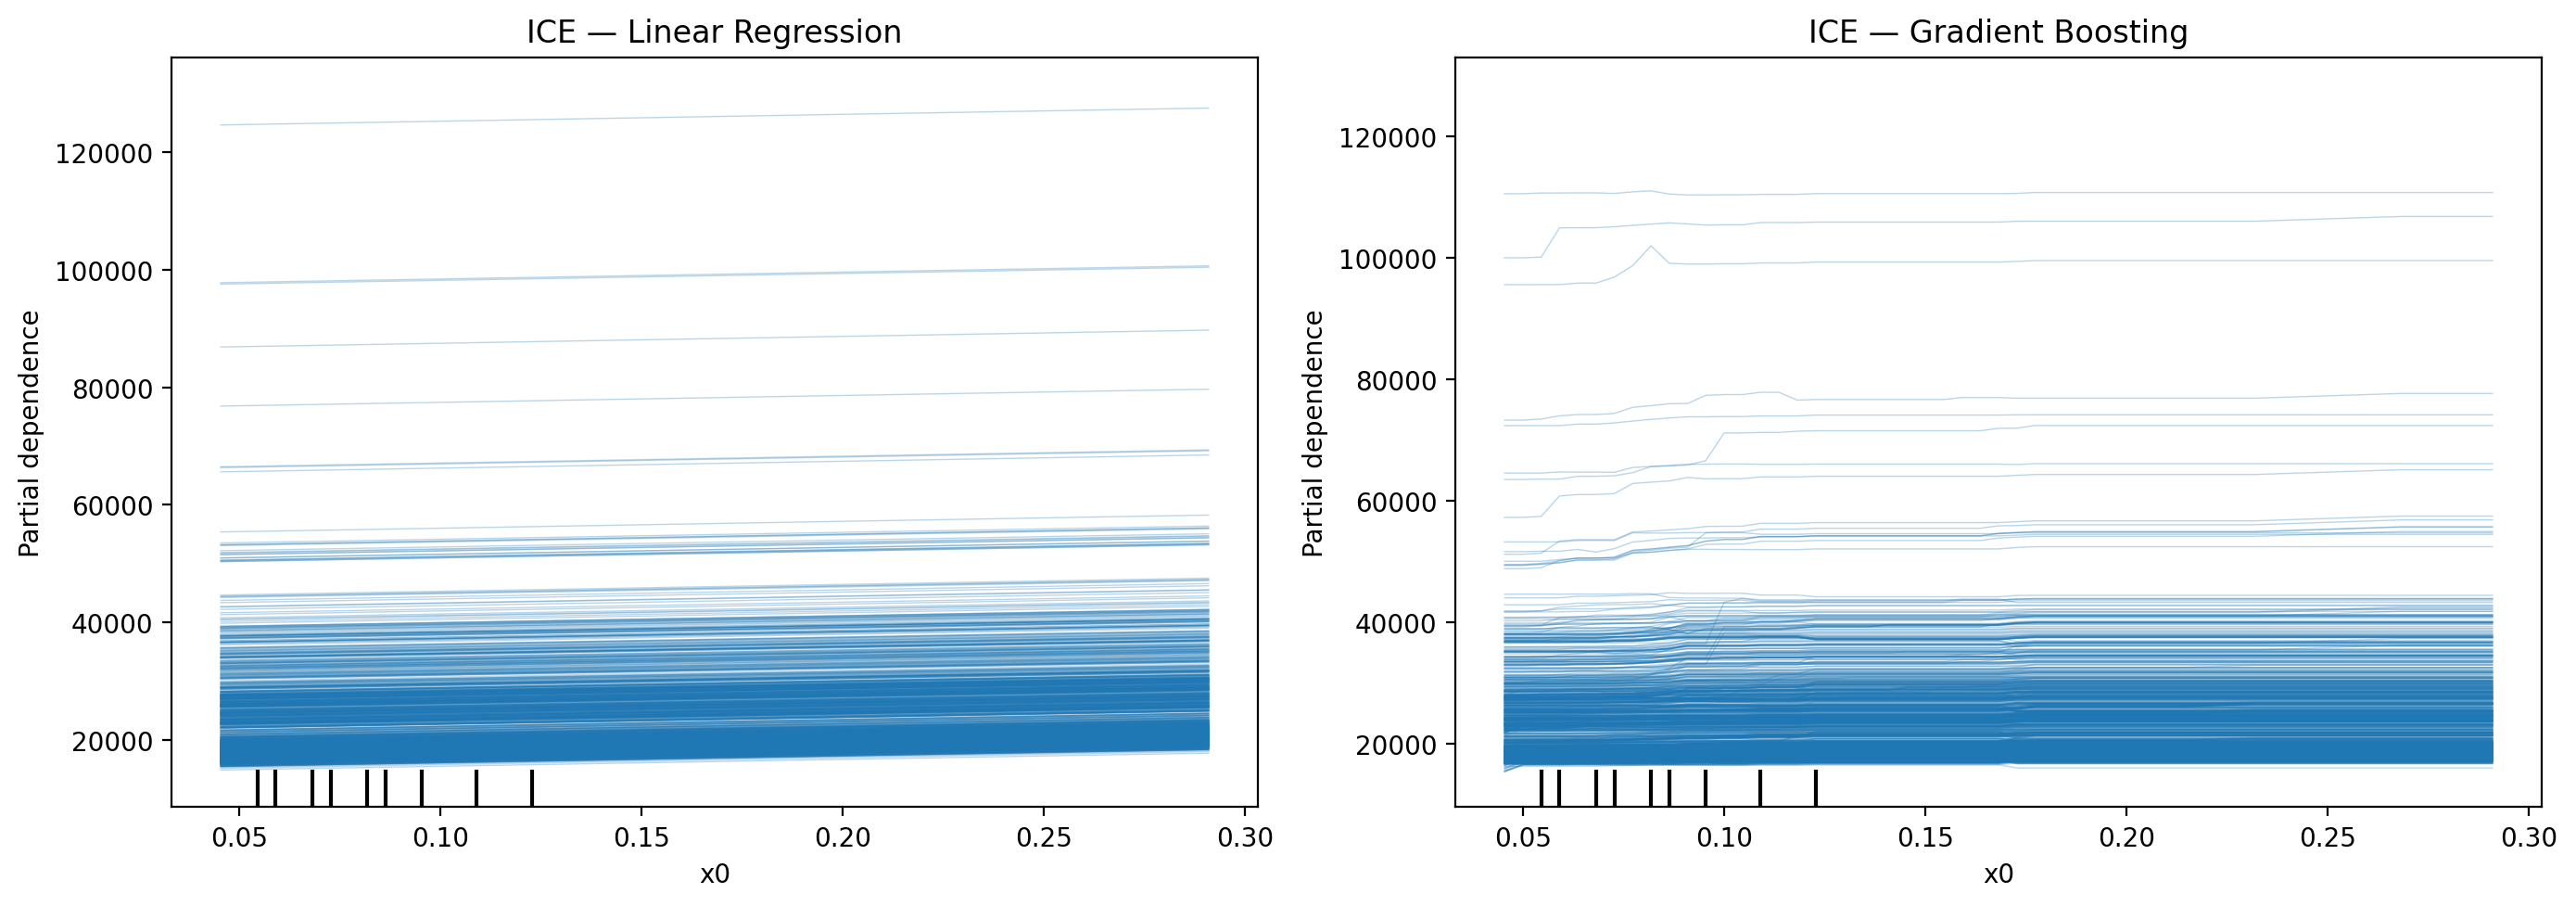

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression ICE
PartialDependenceDisplay.from_estimator(
    model_lr,
    X_test_scaled,
    [feature_idx],
    kind="individual",
    ax=axes[0]
)
axes[0].set_title("ICE — Linear Regression")

# Gradient Boosting ICE
PartialDependenceDisplay.from_estimator(
    model_gb,
    X_test_scaled,
    [feature_idx],
    kind="individual",
    ax=axes[1]
)
axes[1].set_title("ICE — Gradient Boosting")

plt.tight_layout()
plt.show()

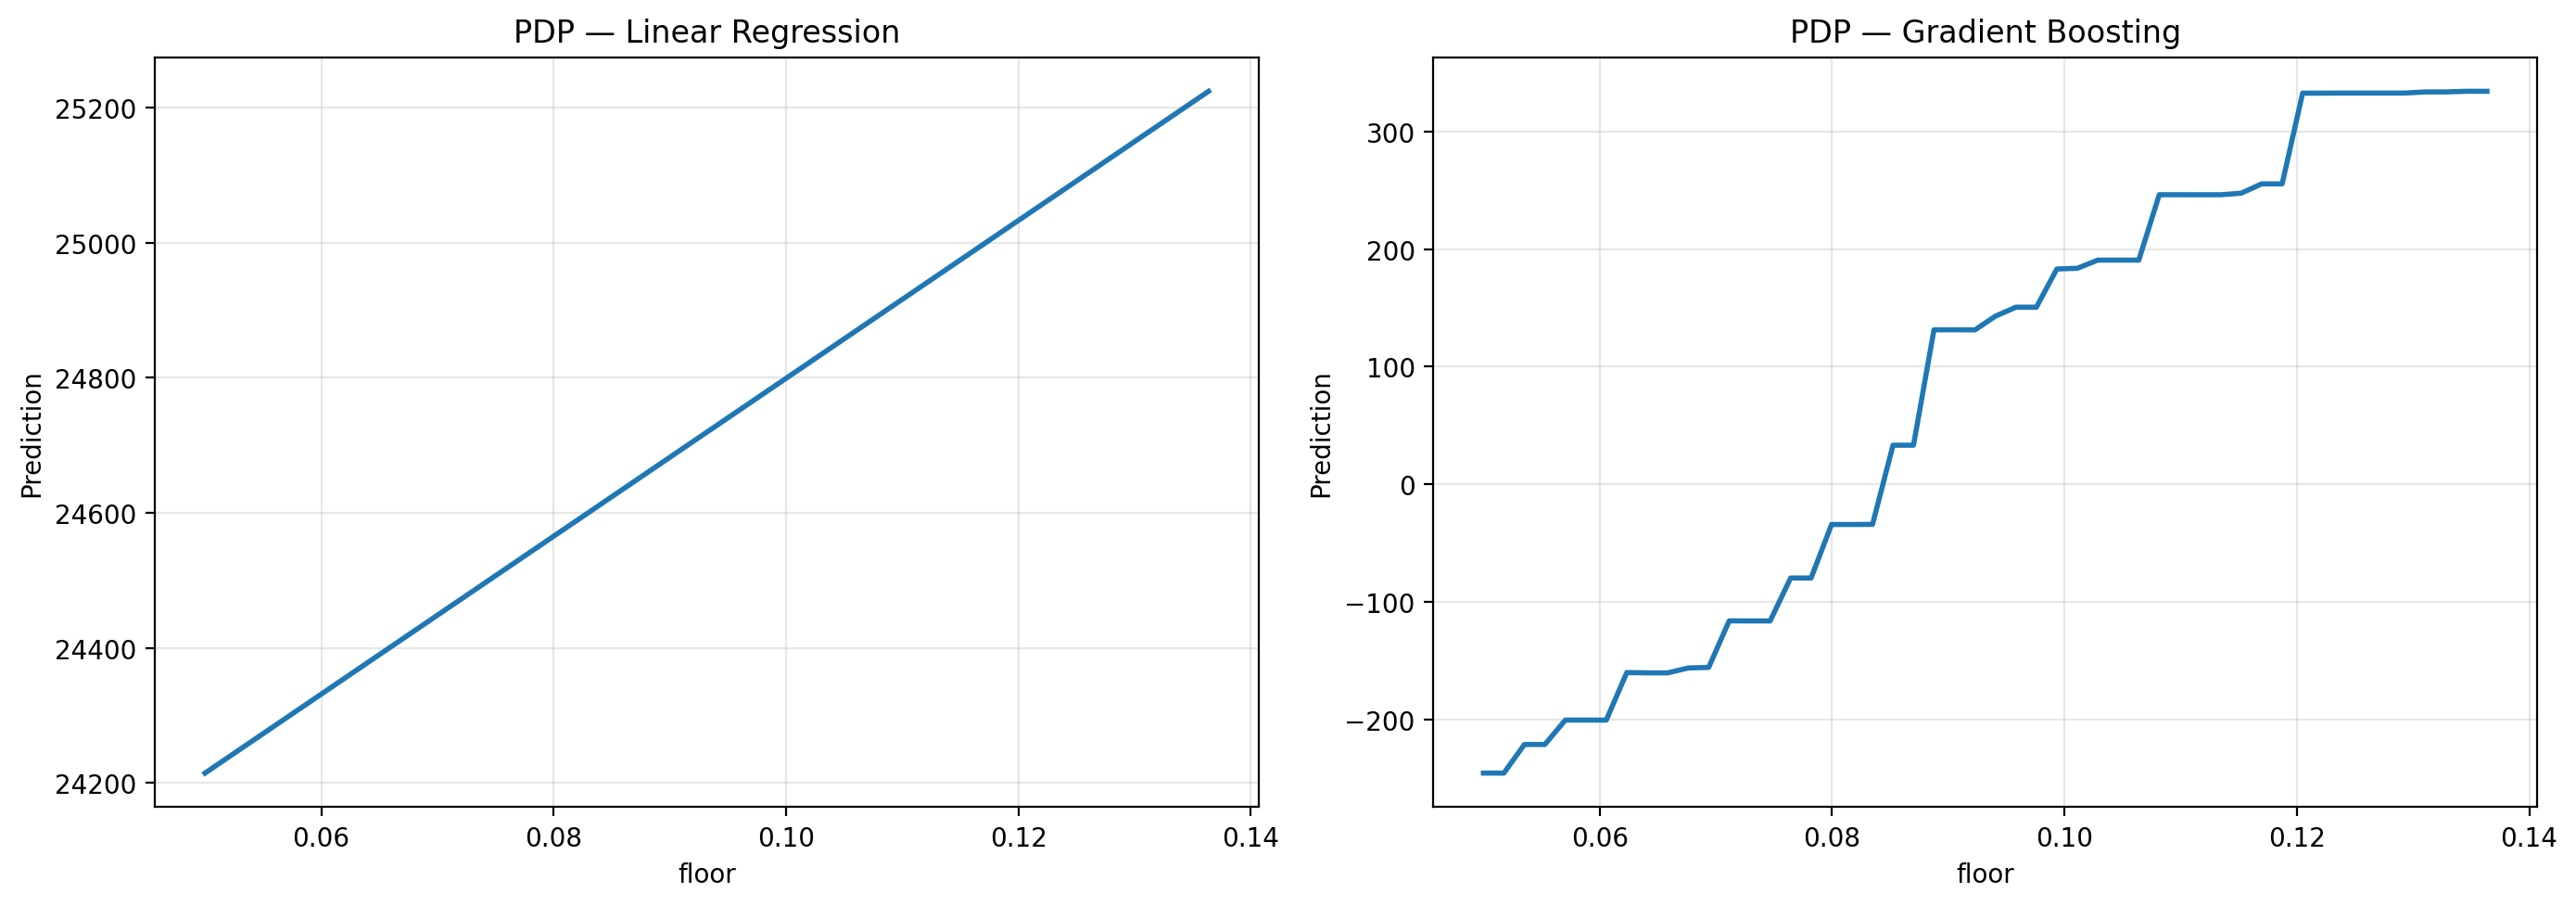

In [137]:
# PDP для Linear Regression
pdp_lr = partial_dependence(
    model_lr,
    X_train_scaled,
    features=[feature_idx],
    grid_resolution=50
)

# PDP для Gradient Boosting
pdp_gb = partial_dependence(
    model_gb,
    X_train_scaled,
    features=[feature_idx],
    grid_resolution=50
)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear
axes[0].plot(
    pdp_lr['grid_values'][0],
    pdp_lr['average'][0],
    linewidth=2
)
axes[0].set_title("PDP — Linear Regression")
axes[0].set_xlabel(feature)
axes[0].set_ylabel("Prediction")
axes[0].grid(True, alpha=0.3)

# Boosting
axes[1].plot(
    pdp_gb['grid_values'][0],
    pdp_gb['average'][0],
    linewidth=2
)
axes[1].set_title("PDP — Gradient Boosting")
axes[1].set_xlabel(feature)
axes[1].set_ylabel("Prediction")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [138]:
X_test_outliers = X_test.copy()

# границы в train
min_val = X_train[feature].min()
max_val = X_train[feature].max()

print("Train min/max:", min_val, max_val)

# случайные объекты
np.random.seed(42)
outlier_indices = np.random.choice(X_test.index, size=10, replace=False)

# случайные экстремальные значения
X_test_outliers.loc[outlier_indices, feature] = np.random.uniform(
    max_val * 5, max_val * 10, size=10
)

X_test_outliers_scaled = scaler.transform(X_test_outliers)

Train min/max: -9.0 211.0


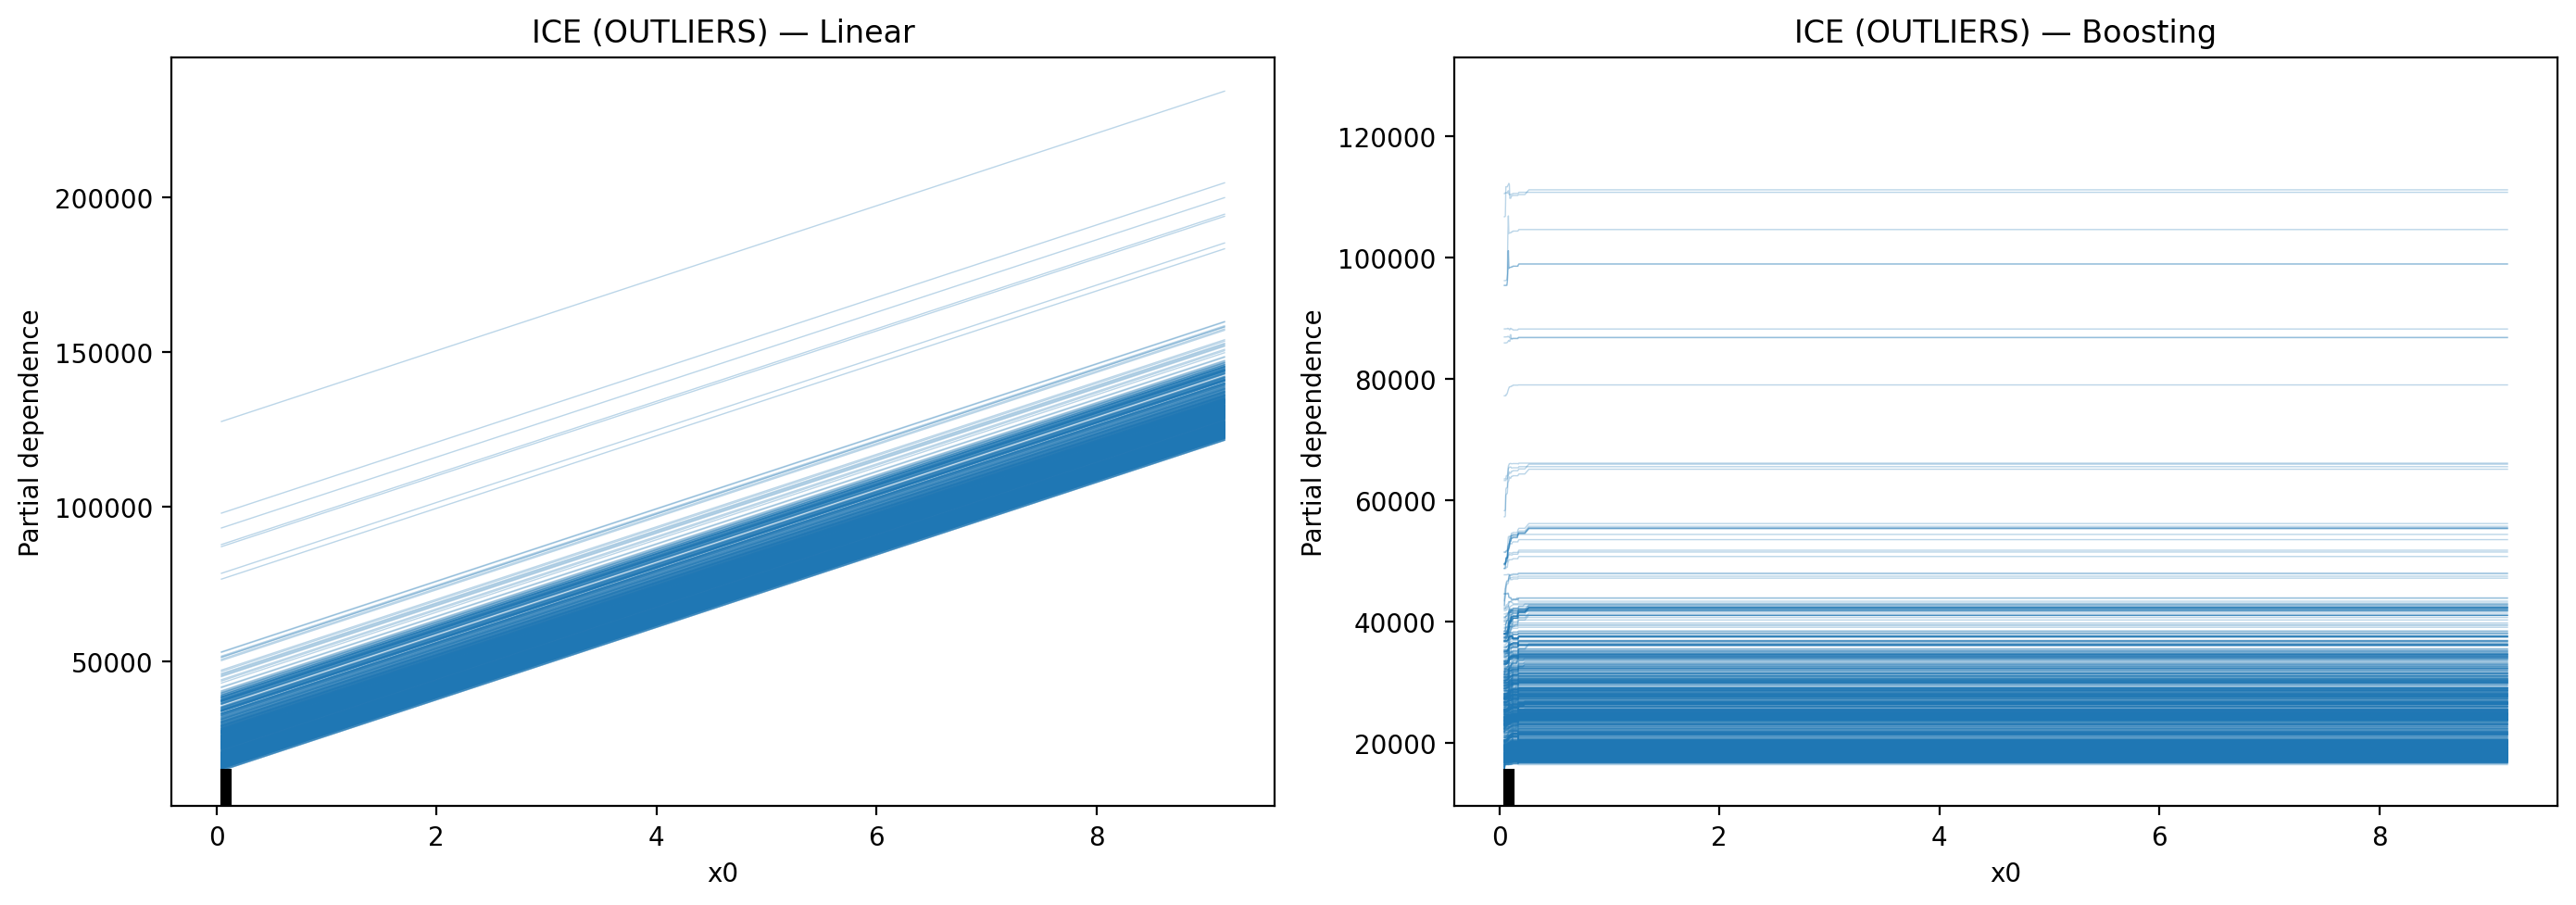

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

PartialDependenceDisplay.from_estimator(
    model_lr,
    X_test_outliers_scaled,
    [feature_idx],
    kind="individual",
    ax=axes[0]
)
axes[0].set_title("ICE (OUTLIERS) — Linear")

PartialDependenceDisplay.from_estimator(
    model_gb,
    X_test_outliers_scaled,
    [feature_idx],
    kind="individual",
    ax=axes[1]
)
axes[1].set_title("ICE (OUTLIERS) — Boosting")

plt.tight_layout()
plt.show()

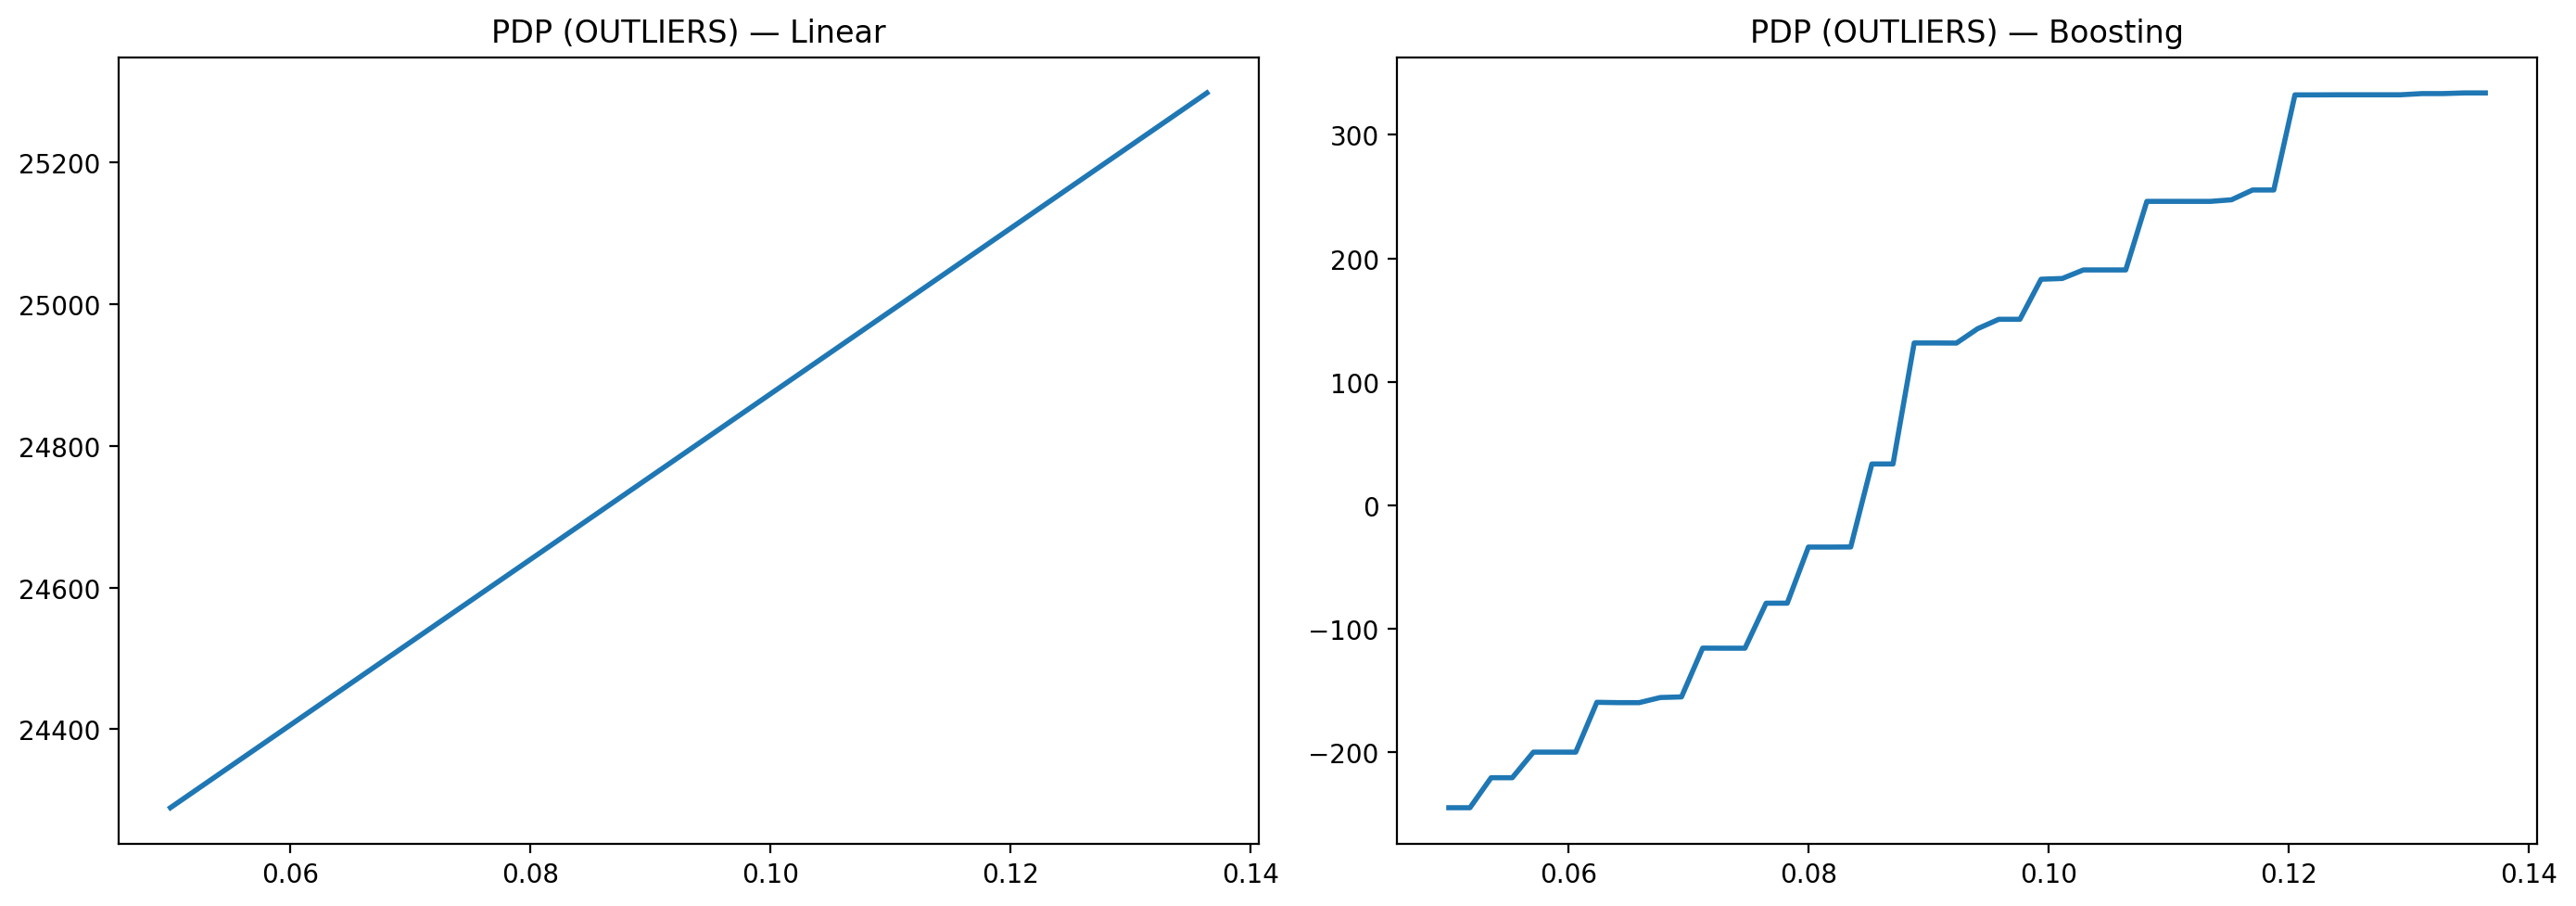

In [140]:
pdp_lr_out = partial_dependence(
    model_lr,
    X_test_outliers_scaled,
    features=[feature_idx],
    grid_resolution=50
)

pdp_gb_out = partial_dependence(
    model_gb,
    X_test_outliers_scaled,
    features=[feature_idx],
    grid_resolution=50
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    pdp_lr_out['grid_values'][0],
    pdp_lr_out['average'][0],
    linewidth=2
)
axes[0].set_title("PDP (OUTLIERS) — Linear")

axes[1].plot(
    pdp_gb_out['grid_values'][0],
    pdp_gb_out['average'][0],
    linewidth=2
)
axes[1].set_title("PDP (OUTLIERS) — Boosting")

plt.tight_layout()
plt.show()

## Вывод 2

### Влияние выхода признаков за диапазон

* После добавления выбросов линейная регрессия продолжает линейный рост, причем значения предсказаний значительно увеличиваются
* ICE для линейной модели резко уходит вверх, что показывает сильную чувствительность к выходу за обучающий диапазон
* Градиентный бустинг практически не реагирует на выбросы, его ICE-кривые остаются почти неизменными
* PDP для обеих моделей практически не изменился после добавления выбросов

### Интерпретация результатов

* Линейная модель экстраполирует зависимость за пределами обучающего диапазона, что приводит к неконтролируемому росту предсказаний
* Бустинг, основанный на деревьях, не умеет экстраполировать и фактически "обрезает" значения, оставаясь в пределах обученного диапазона
* Это объясняет устойчивость бустинга к выбросам и нестабильность линейной модели

### Итог

* Линейная регрессия чувствительна к выходу признаков за диапазон и может давать неадекватные предсказания
* Градиентный бустинг устойчив к таким ситуациям, но теряет способность к экстраполяции
* Результаты полностью соответствуют теоретическим ожиданиям


## Задание 2.1* 1 балл
Проанализируйте также еще один признак

In [141]:
feature = "location_logs_count_mean"

# Масштабирование
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Индекс признака
feature_idx = X.columns.get_loc(feature)

# Модели
model_lr = LinearRegression()
model_gb = GradientBoostingRegressor(max_depth=5, random_state=42)

# Обучение
model_lr.fit(X_train_scaled, y_train)
model_gb.fit(X_train_scaled, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

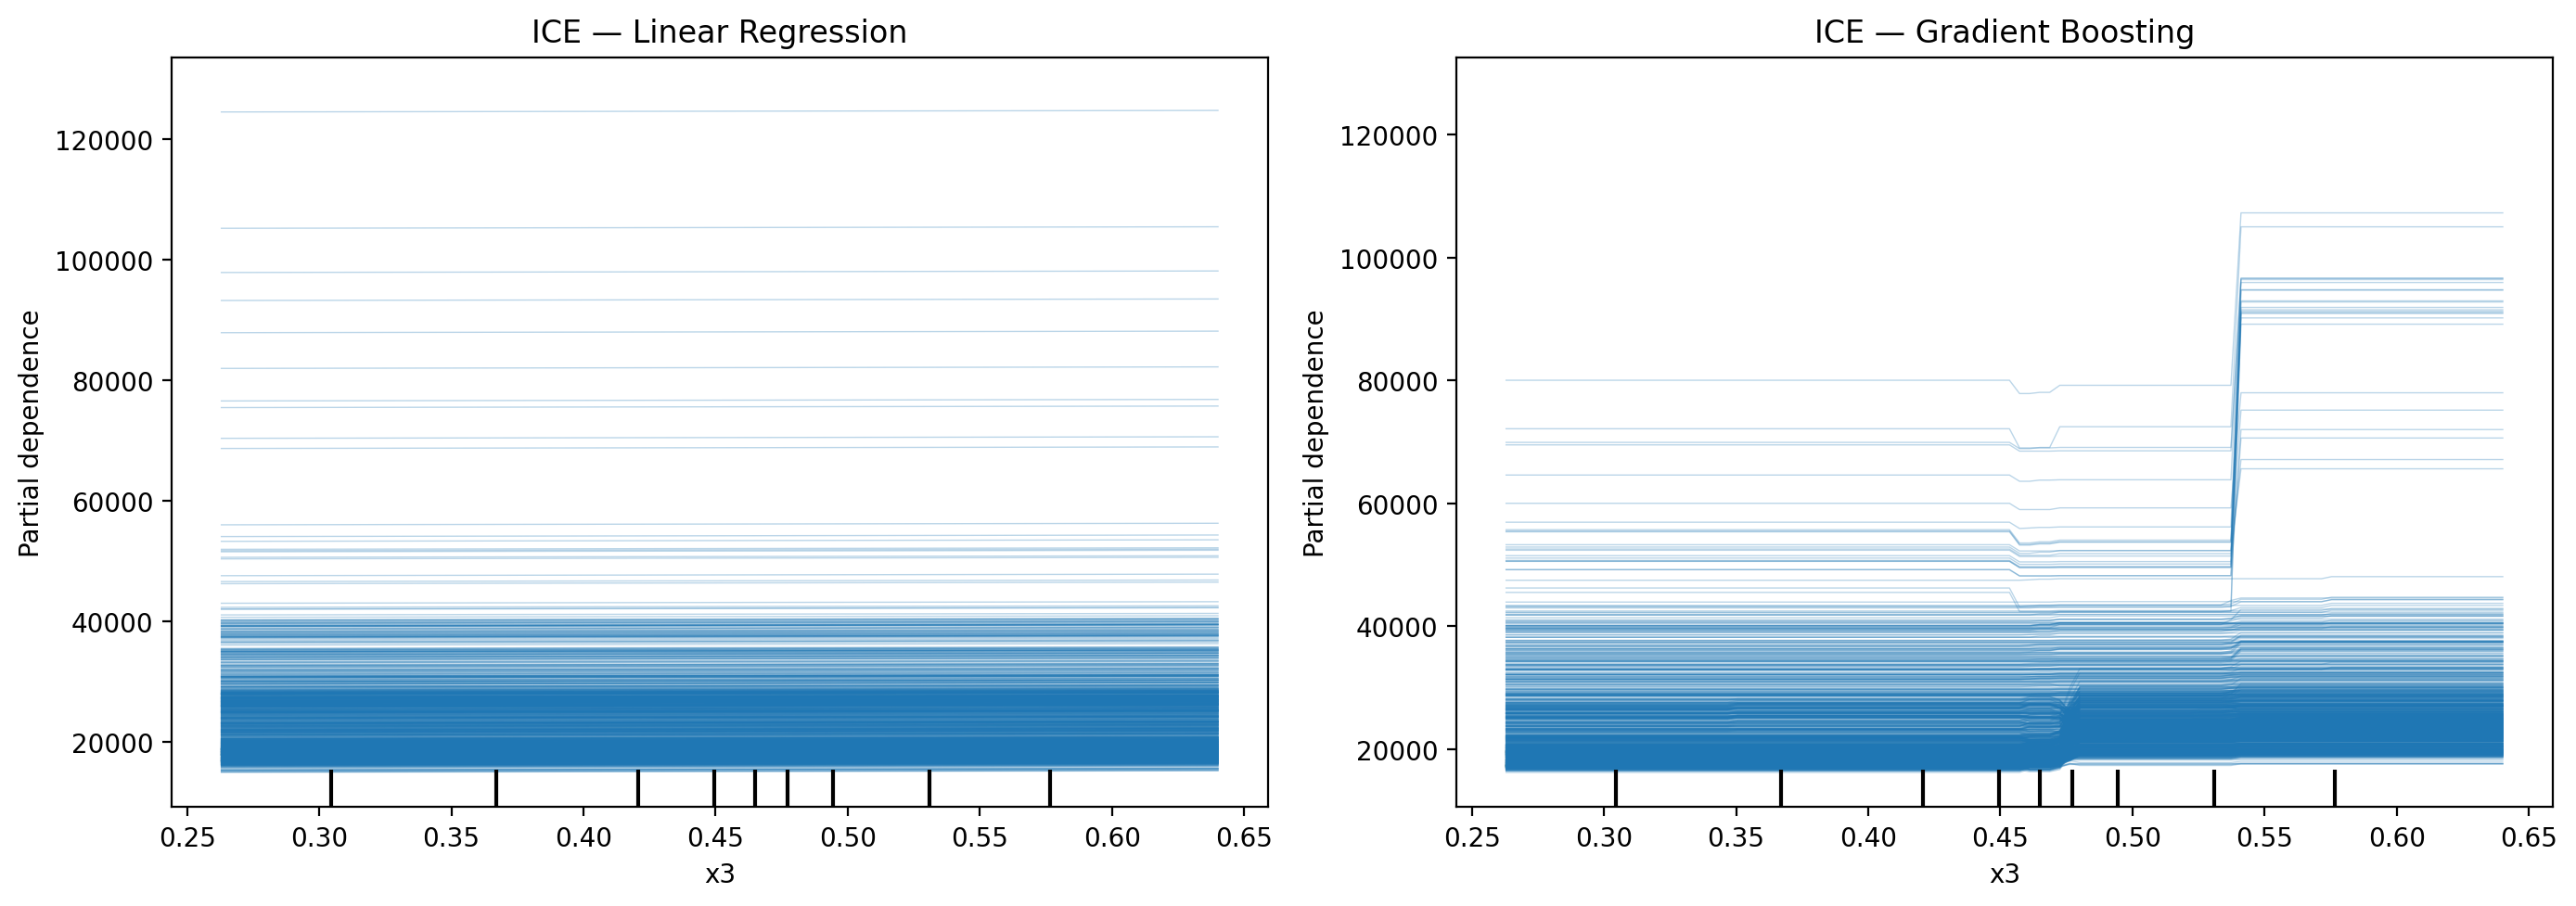

In [142]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression ICE
PartialDependenceDisplay.from_estimator(
    model_lr,
    X_test_scaled,
    [feature_idx],
    kind="individual",
    ax=axes[0]
)
axes[0].set_title("ICE — Linear Regression")

# Gradient Boosting ICE
PartialDependenceDisplay.from_estimator(
    model_gb,
    X_test_scaled,
    [feature_idx],
    kind="individual",
    ax=axes[1]
)
axes[1].set_title("ICE — Gradient Boosting")

plt.tight_layout()
plt.show()

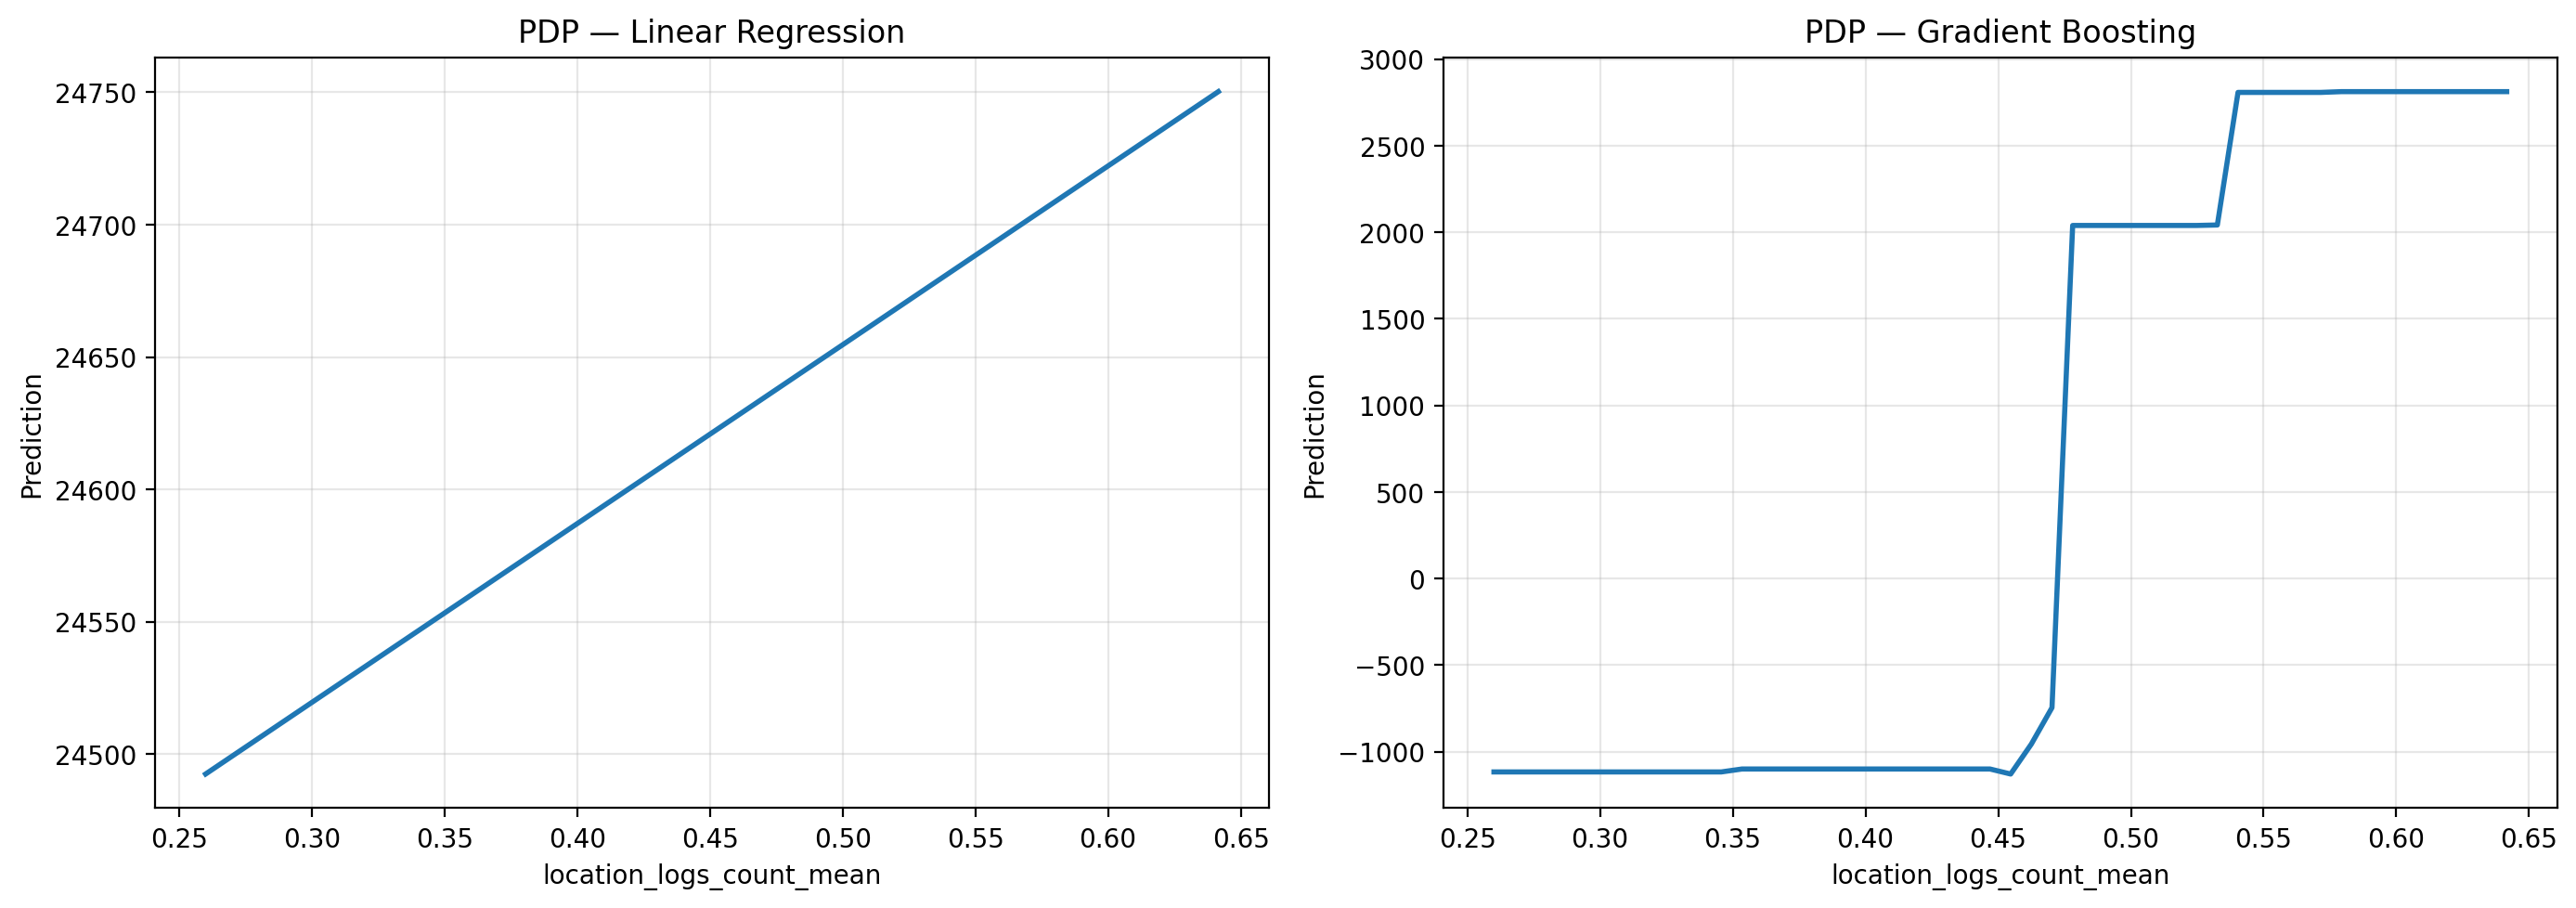

In [143]:
# PDP для Linear Regression
pdp_lr = partial_dependence(
    model_lr,
    X_train_scaled,
    features=[feature_idx],
    grid_resolution=50
)

# PDP для Gradient Boosting
pdp_gb = partial_dependence(
    model_gb,
    X_train_scaled,
    features=[feature_idx],
    grid_resolution=50
)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear
axes[0].plot(
    pdp_lr['grid_values'][0],
    pdp_lr['average'][0],
    linewidth=2
)
axes[0].set_title("PDP — Linear Regression")
axes[0].set_xlabel(feature)
axes[0].set_ylabel("Prediction")
axes[0].grid(True, alpha=0.3)

# Boosting
axes[1].plot(
    pdp_gb['grid_values'][0],
    pdp_gb['average'][0],
    linewidth=2
)
axes[1].set_title("PDP — Gradient Boosting")
axes[1].set_xlabel(feature)
axes[1].set_ylabel("Prediction")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [144]:
X_test_outliers = X_test.copy()

# границы в train
min_val = X_train[feature].min()
max_val = X_train[feature].max()

print("Train min/max:", min_val, max_val)

# случайные объекты
np.random.seed(42)
outlier_indices = np.random.choice(X_test.index, size=10, replace=False)

# случайные экстремальные значения
X_test_outliers.loc[outlier_indices, feature] = np.random.uniform(
    max_val * 5, max_val * 10, size=10
)

X_test_outliers_scaled = scaler.transform(X_test_outliers)

Train min/max: 13.178135908294776 33.396233821885644


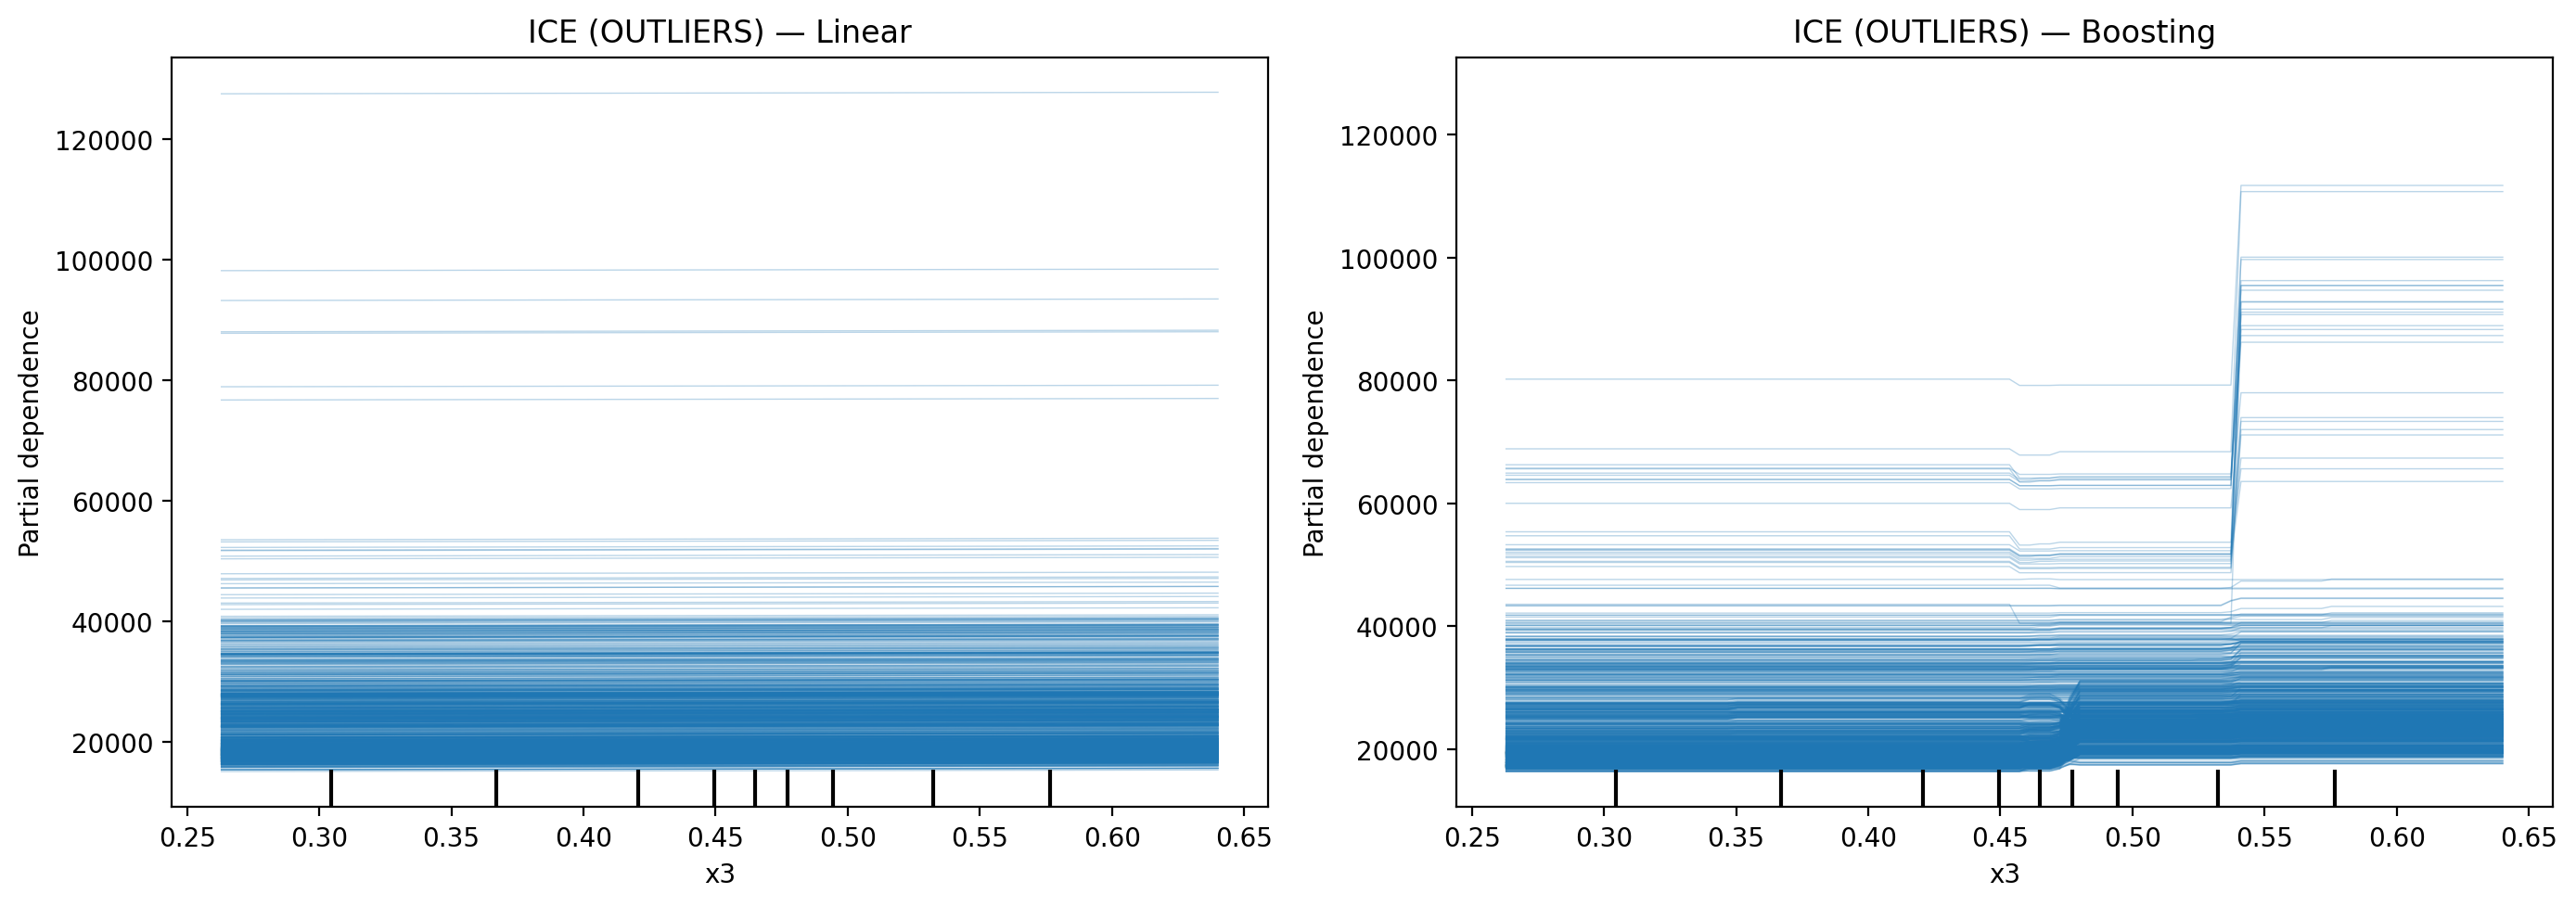

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

PartialDependenceDisplay.from_estimator(
    model_lr,
    X_test_outliers_scaled,
    [feature_idx],
    kind="individual",
    ax=axes[0]
)
axes[0].set_title("ICE (OUTLIERS) — Linear")

PartialDependenceDisplay.from_estimator(
    model_gb,
    X_test_outliers_scaled,
    [feature_idx],
    kind="individual",
    ax=axes[1]
)
axes[1].set_title("ICE (OUTLIERS) — Boosting")

plt.tight_layout()
plt.show()

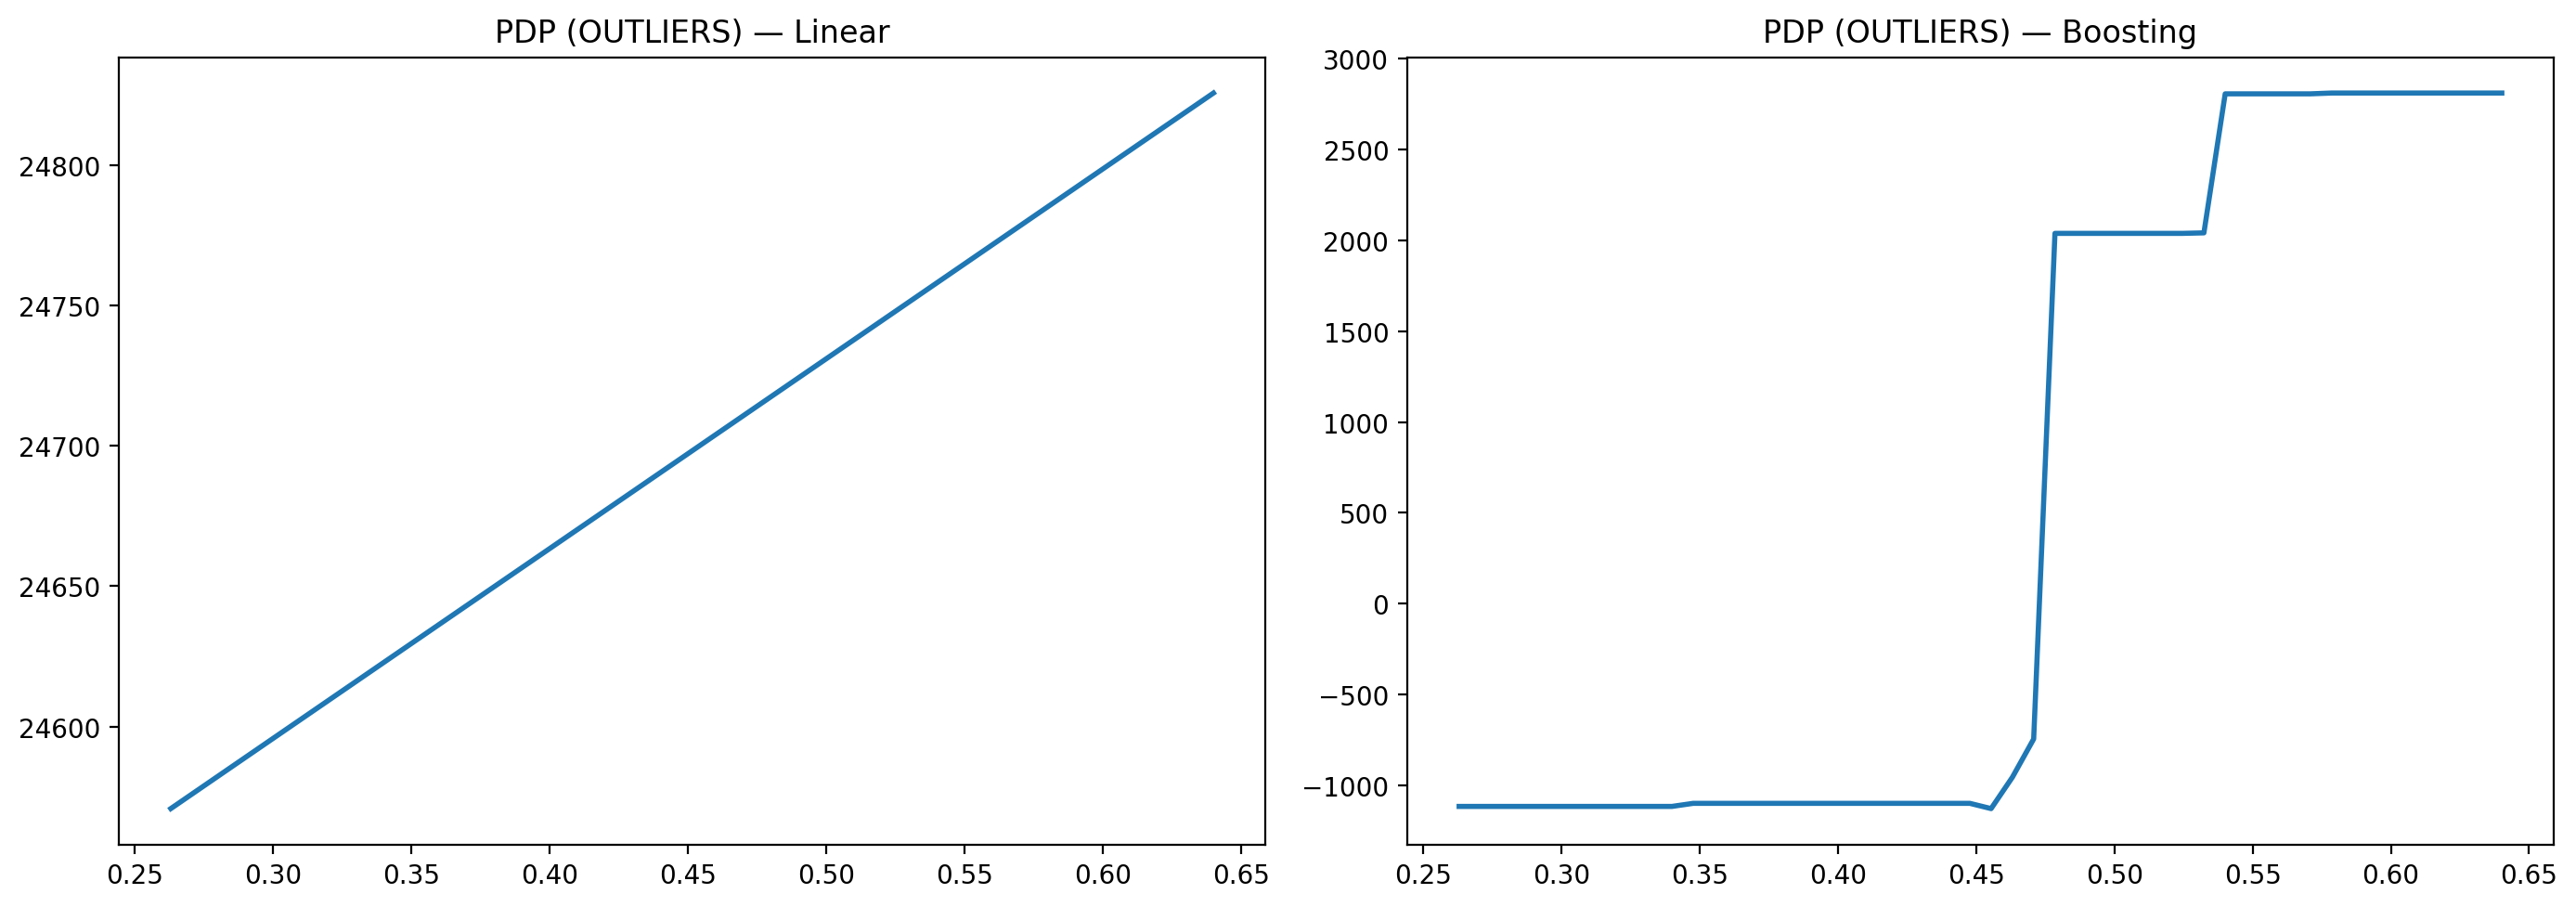

In [146]:
pdp_lr_out = partial_dependence(
    model_lr,
    X_test_outliers_scaled,
    features=[feature_idx],
    grid_resolution=50
)

pdp_gb_out = partial_dependence(
    model_gb,
    X_test_outliers_scaled,
    features=[feature_idx],
    grid_resolution=50
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    pdp_lr_out['grid_values'][0],
    pdp_lr_out['average'][0],
    linewidth=2
)
axes[0].set_title("PDP (OUTLIERS) — Linear")

axes[1].plot(
    pdp_gb_out['grid_values'][0],
    pdp_gb_out['average'][0],
    linewidth=2
)
axes[1].set_title("PDP (OUTLIERS) — Boosting")

plt.tight_layout()
plt.show()

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории

In [147]:
model = GradientBoostingRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [148]:
np.random.seed(42)
indices = np.random.choice(len(X_test), 20, replace=False)

X_subset = X_test.iloc[indices].copy()

In [149]:
feature = "location_logs_count_mean"
feature_idx = X.columns.get_loc(feature)

# медиана по train
base_value = X_train[feature].median()
print("Base value:", base_value)

Base value: 22.57428654538892


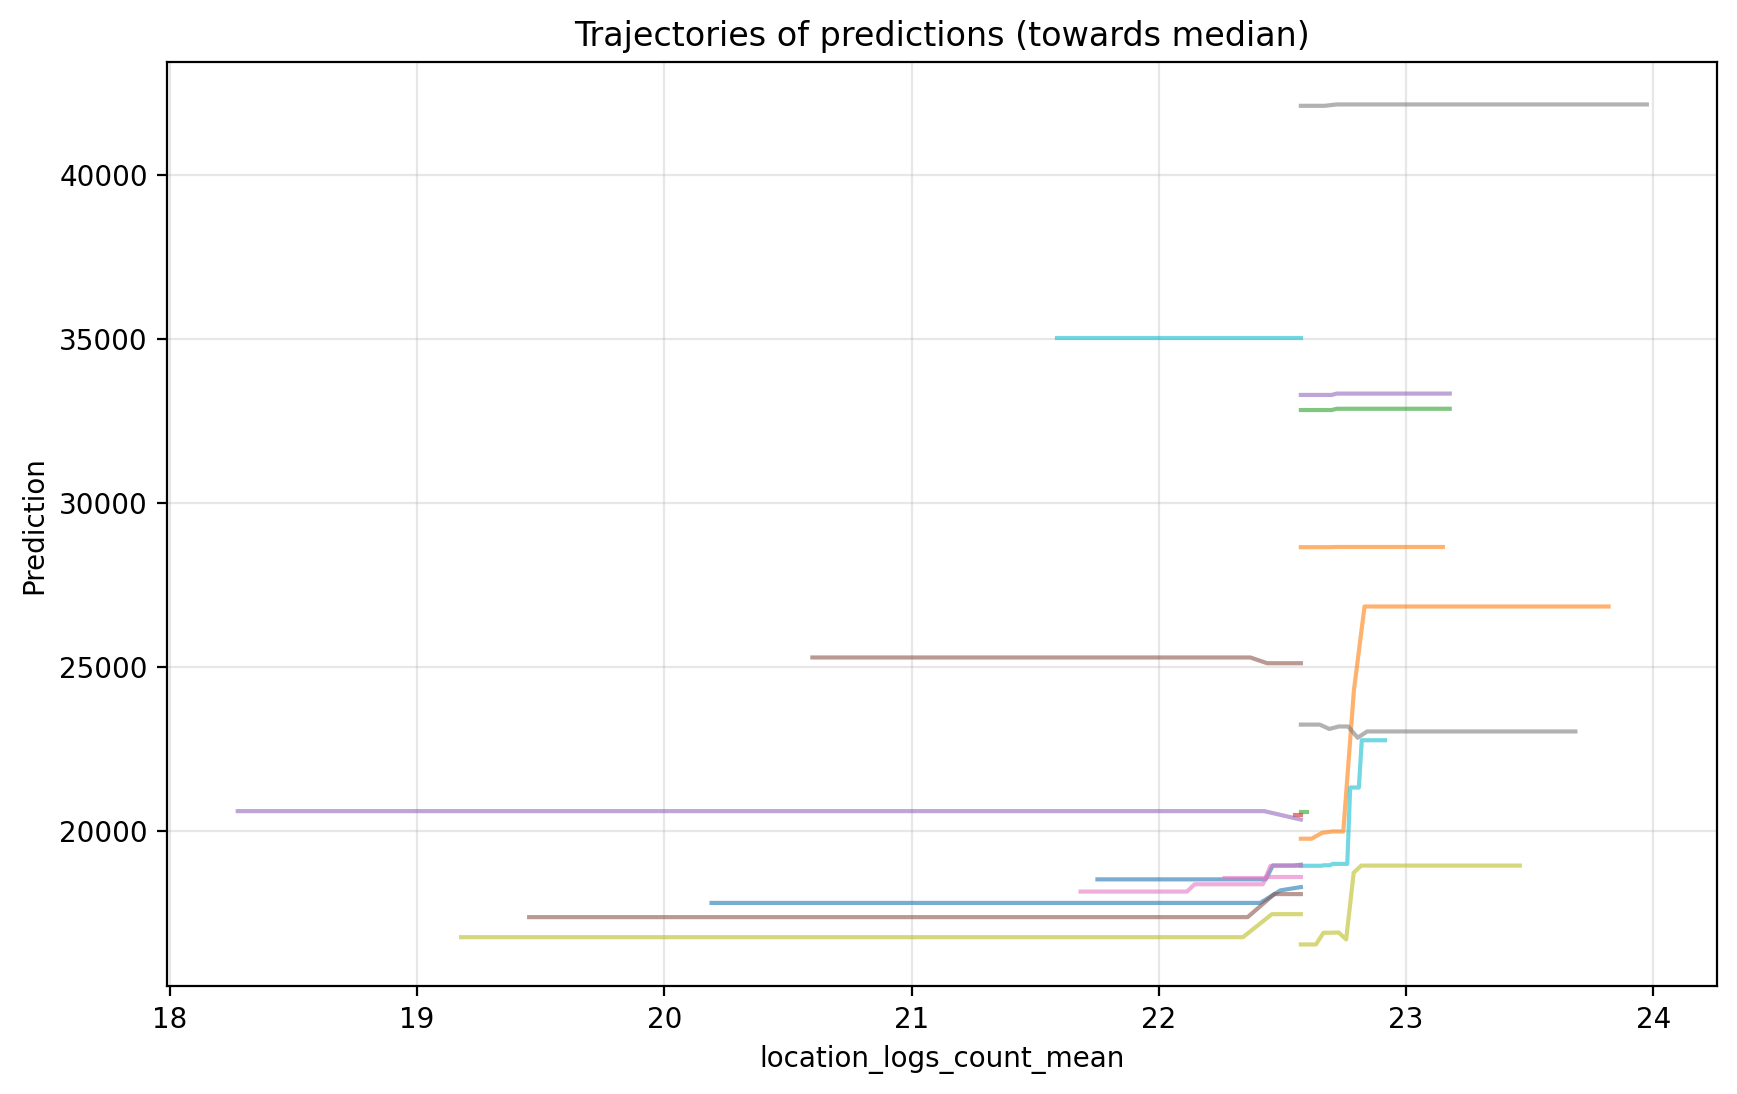

In [150]:
n_steps = 30

plt.figure(figsize=(10, 6))

for i in range(len(X_subset)):
    x = X_subset.iloc[i].copy()
    
    current_value = x[feature]
    
    # линейная интерполяция
    values = np.linspace(current_value, base_value, n_steps)
    
    preds = []
    
    for v in values:
        x_mod = x.copy()
        x_mod[feature] = v
        
        pred = model.predict([x_mod])[0]
        preds.append(pred)
    
    plt.plot(values, preds, alpha=0.6)

plt.xlabel(feature)
plt.ylabel("Prediction")
plt.title("Trajectories of predictions (towards median)")
plt.grid(alpha=0.3)
plt.show()

## Задание 3.1 (*)
Проанализируйте также еще один признак

In [151]:
feature2 = "square"
base_value2 = X_train[feature2].median()
print("Base value:", base_value2)

Base value: 51.76


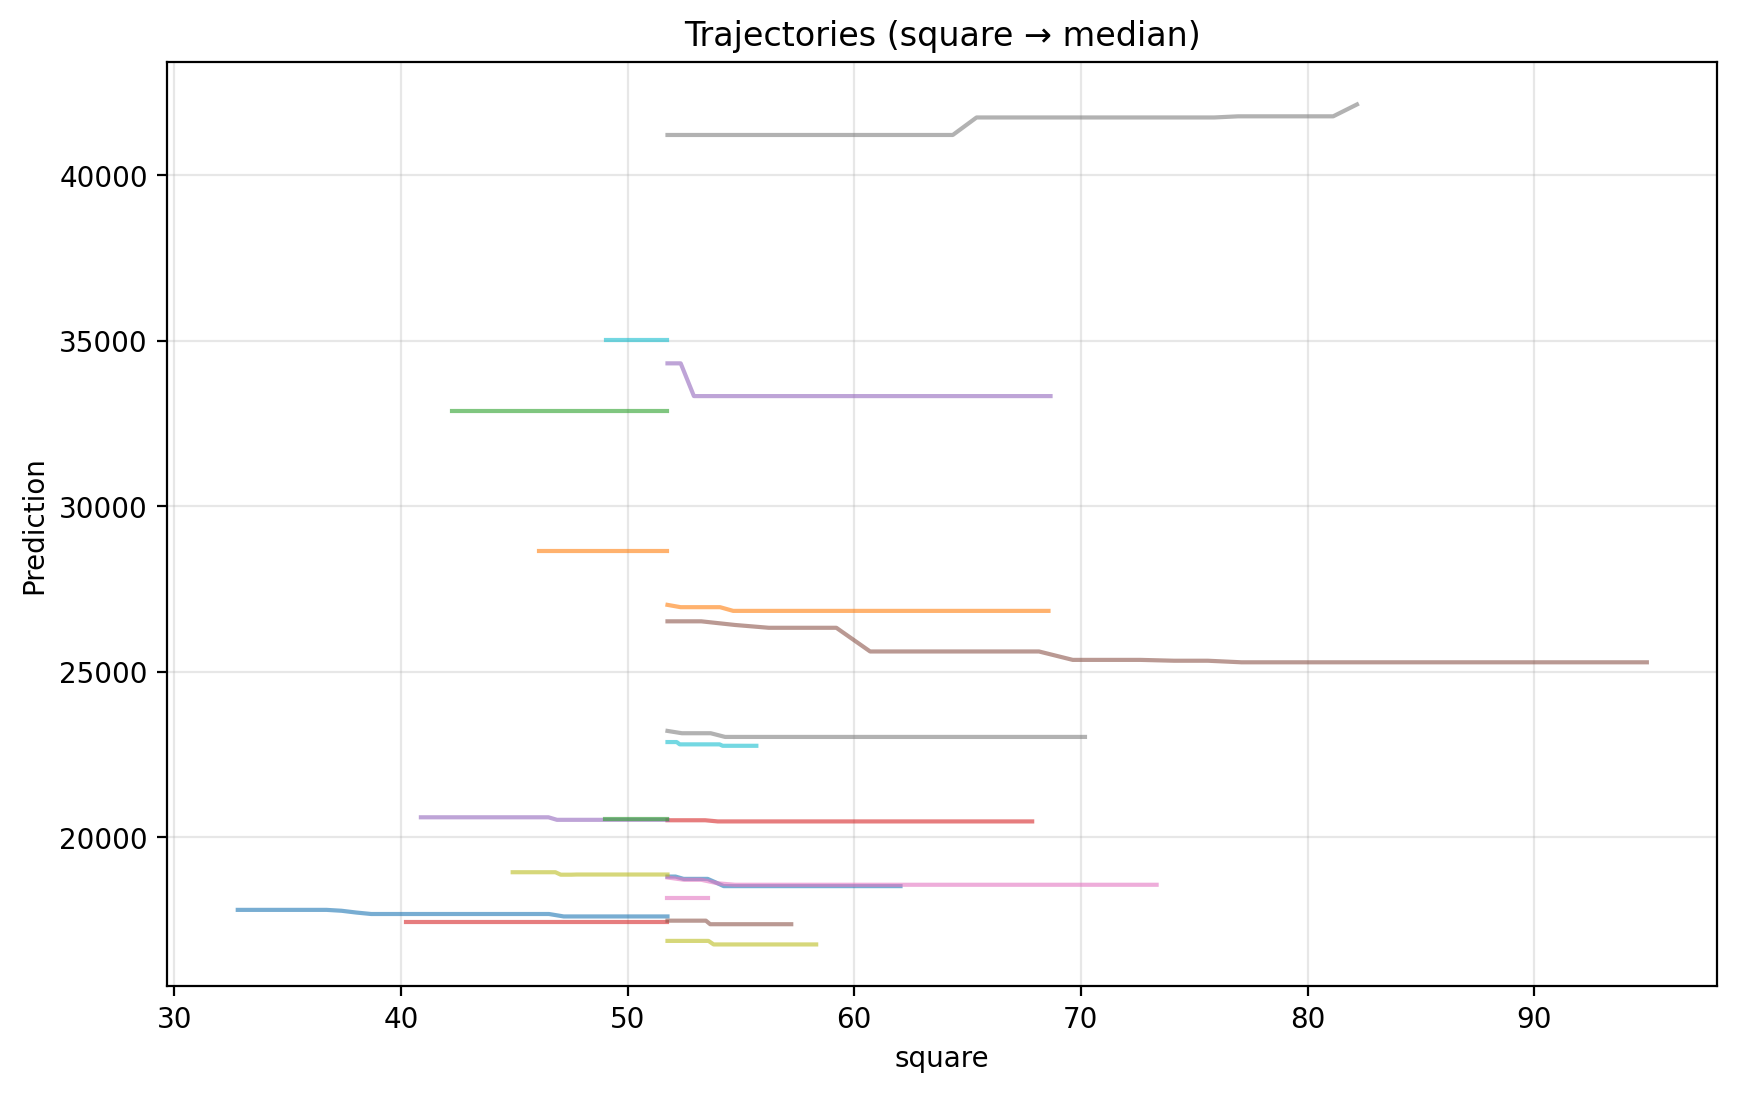

In [152]:
plt.figure(figsize=(10, 6))

for i in range(len(X_subset)):
    x = X_subset.iloc[i].copy()
    
    current_value = x[feature2]
    
    values = np.linspace(current_value, base_value2, n_steps)
    
    preds = []
    
    for v in values:
        x_mod = x.copy()
        x_mod[feature2] = v
        
        pred = model.predict([x_mod])[0]
        preds.append(pred)
    
    plt.plot(values, preds, alpha=0.6)

plt.xlabel(feature2)
plt.ylabel("Prediction")
plt.title("Trajectories (square → median)")
plt.grid(alpha=0.3)
plt.show()

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

In [153]:
!pip install -qU pyALE;


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [154]:
from PyALE import ale

feature = "square"

In [155]:
model_lr = LinearRegression()
model_gb = GradientBoostingRegressor(max_depth=5, random_state=42)

model_lr.fit(X_train, y_train)
model_gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

PyALE._ALE_generic:INFO: Continuous feature detected.


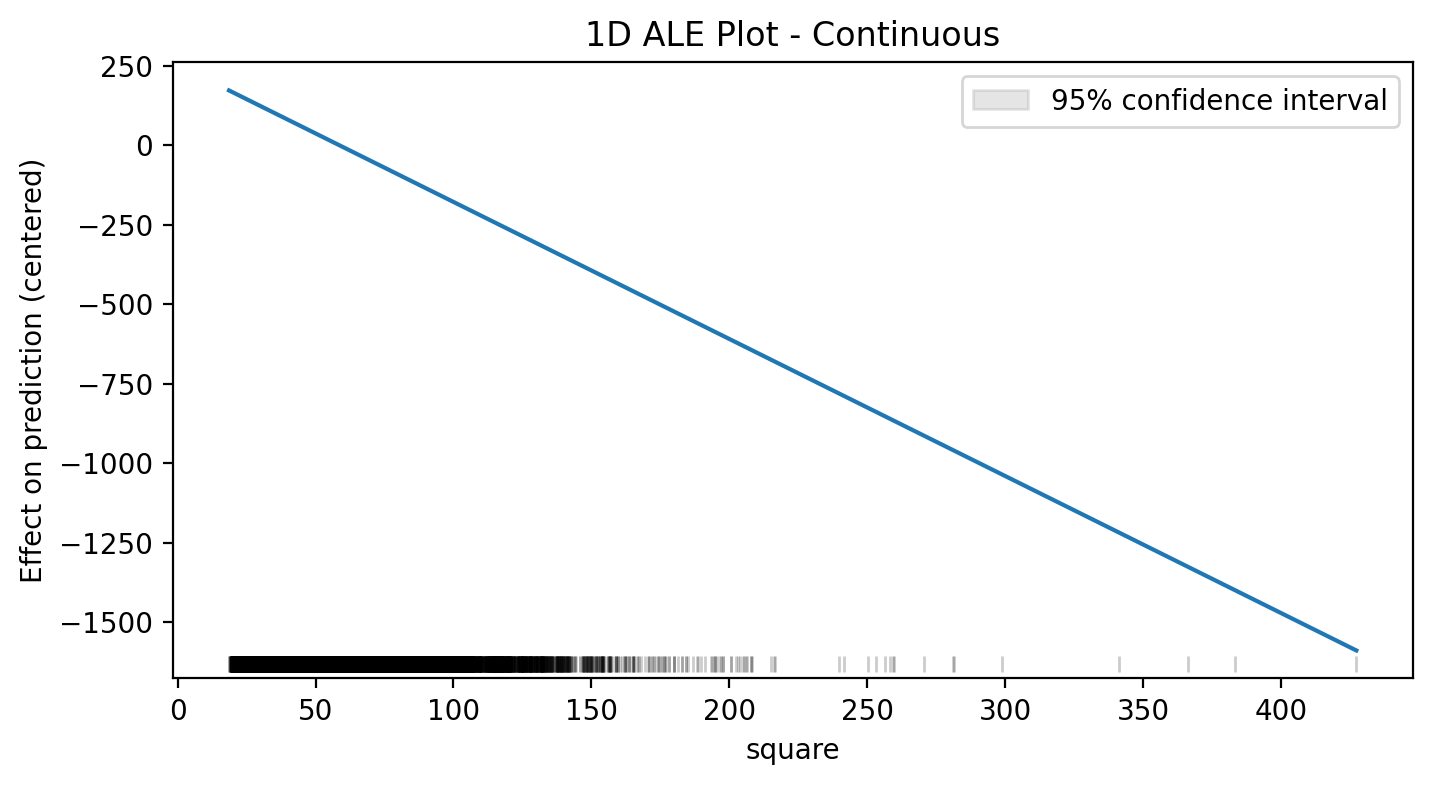

In [171]:
ale_lr = ale(
    X=X_train,
    model=model_lr,
    feature=[feature],
    grid_size=100,   # интервалы отсутствуют из-за однородности локальных эффектов
    include_CI=True
)

PyALE._ALE_generic:INFO: Continuous feature detected.


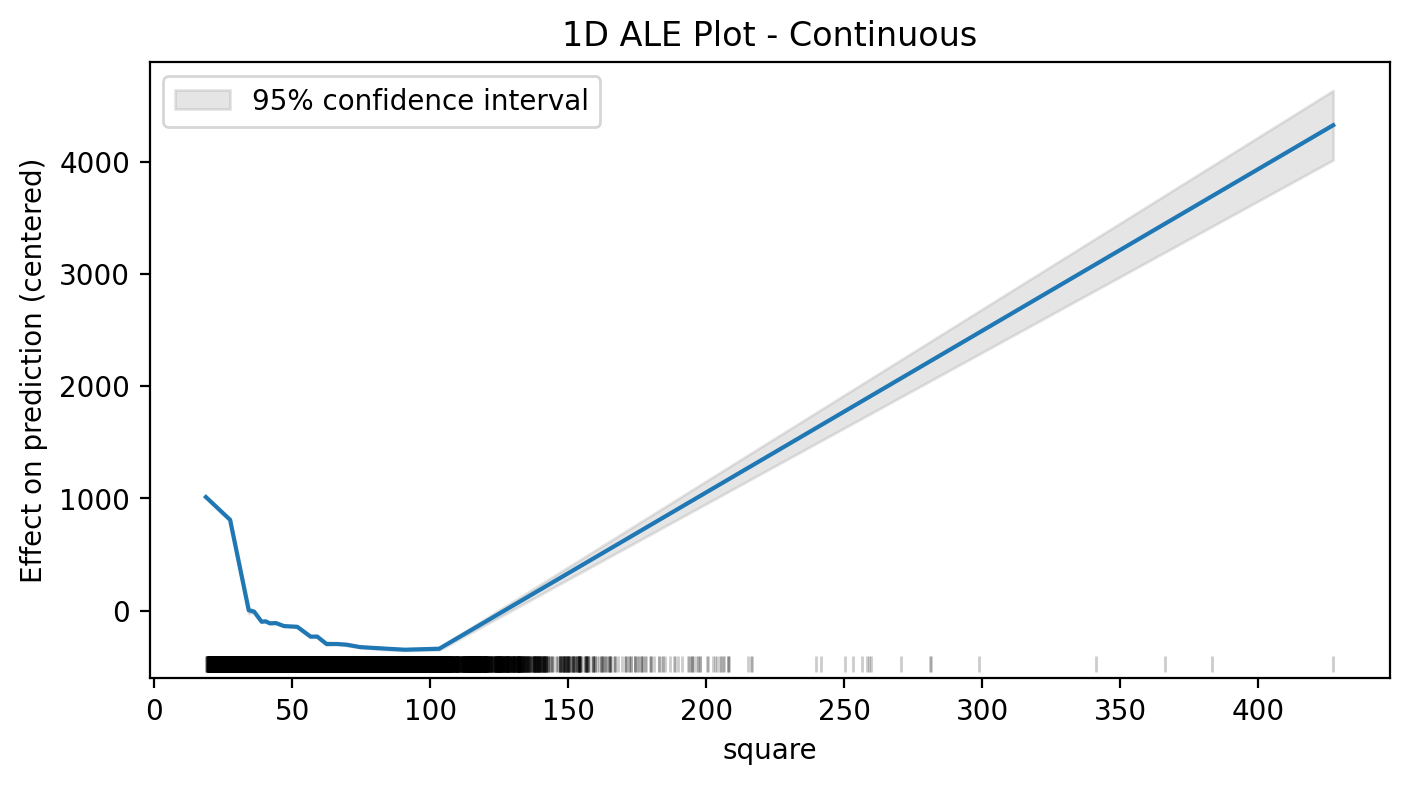

In [157]:
ale_gb = ale(
    X=X_train,
    model=model_gb,
    feature=[feature],
    grid_size=20,
    include_CI=True
)

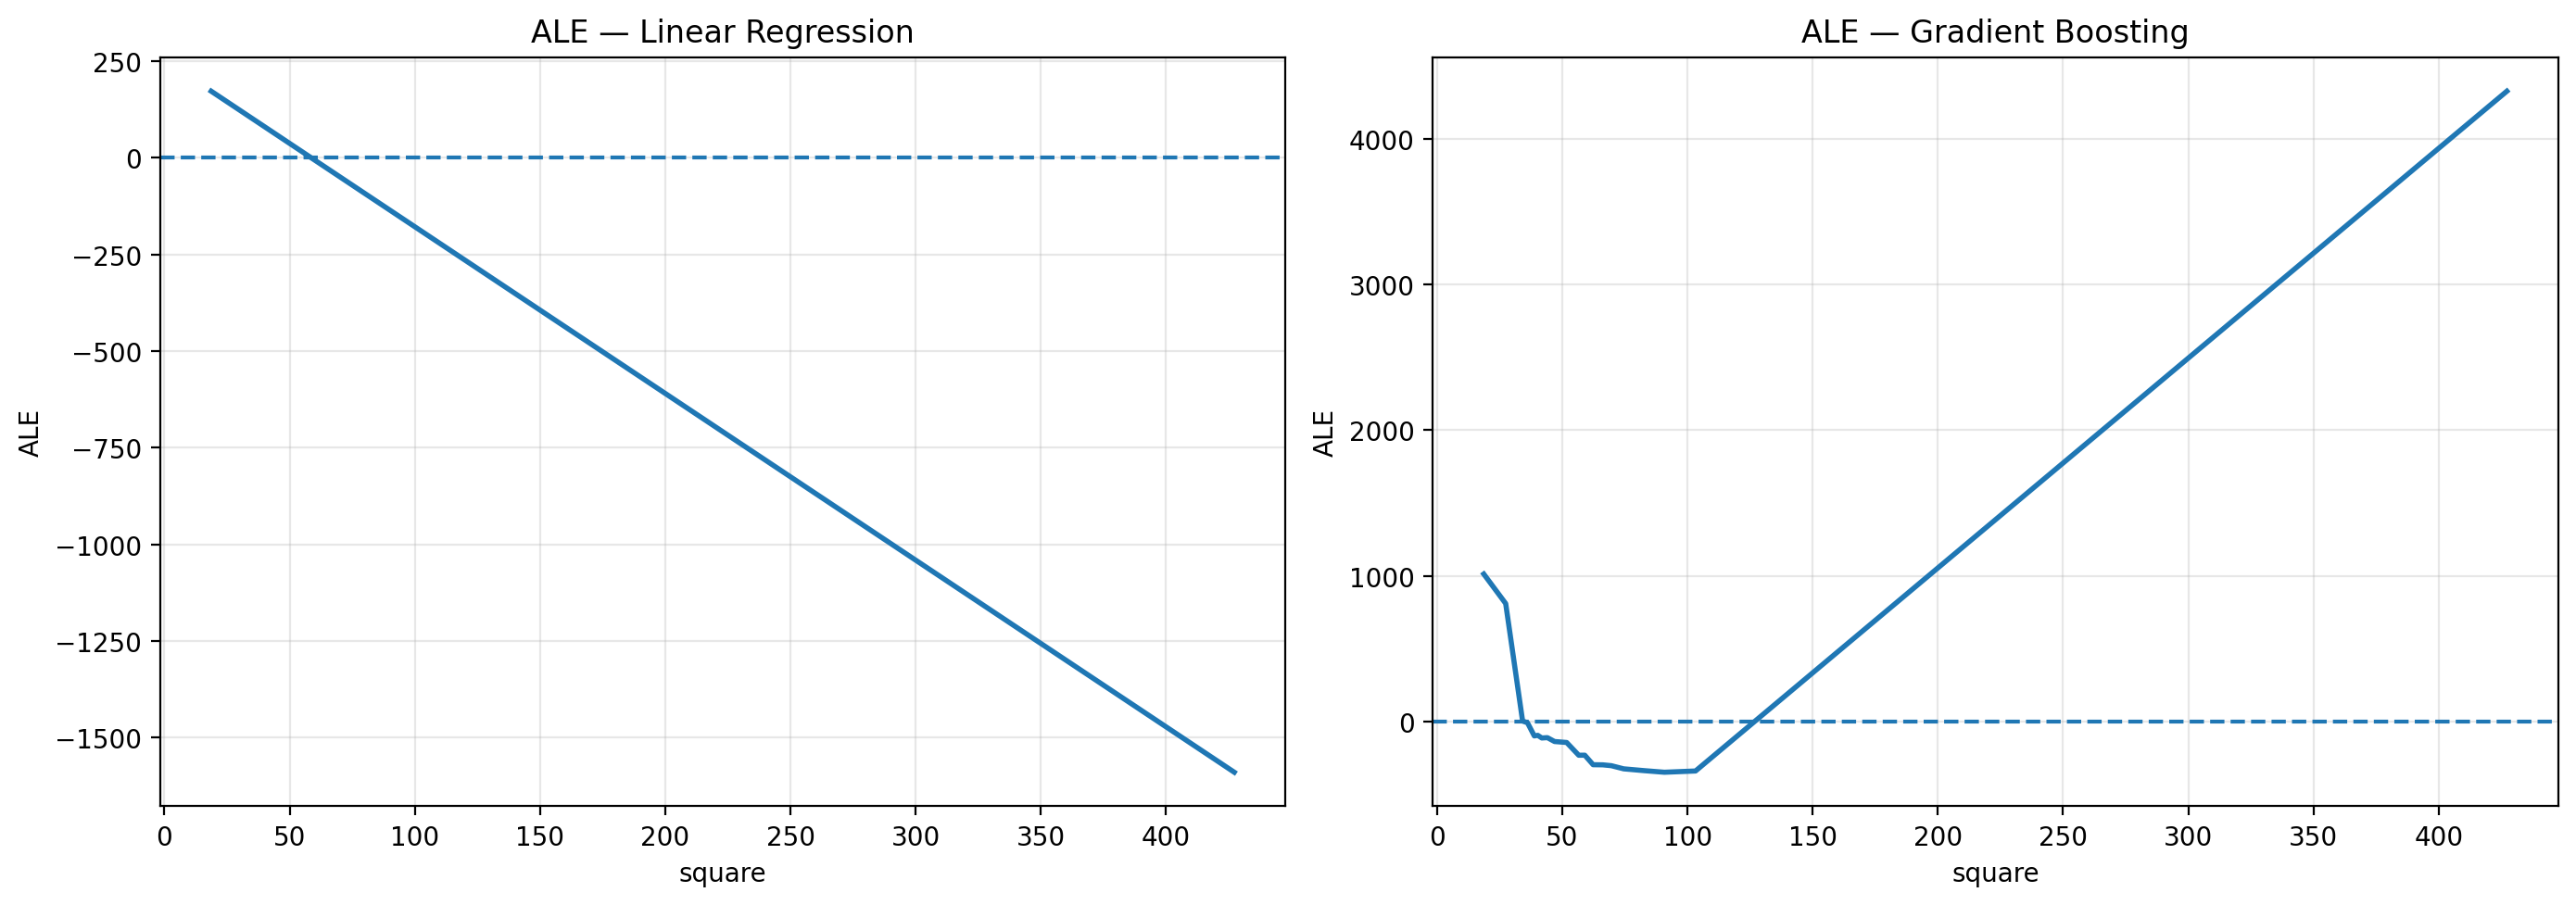

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression
axes[0].plot(ale_lr.index, ale_lr['eff'], linewidth=2)

# CI
if 'lower' in ale_lr.columns and 'upper' in ale_lr.columns:
    axes[0].fill_between(
        ale_lr.index,
        ale_lr['lower'],
        ale_lr['upper'],
        alpha=0.2
    )

axes[0].axhline(0, linestyle='--')
axes[0].set_title("ALE — Linear Regression")
axes[0].set_xlabel(feature)
axes[0].set_ylabel("ALE")
axes[0].grid(alpha=0.3)


# Gradient Boosting
axes[1].plot(ale_gb.index, ale_gb['eff'], linewidth=2)

if 'lower' in ale_gb.columns and 'upper' in ale_gb.columns:
    axes[1].fill_between(
        ale_gb.index,
        ale_gb['lower'],
        ale_gb['upper'],
        alpha=0.2
    )

axes[1].axhline(0, linestyle='--')
axes[1].set_title("ALE — Gradient Boosting")
axes[1].set_xlabel(feature)
axes[1].set_ylabel("ALE")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Вывод 4

### Интерпретация доверительных интервалов

* Для линейной регрессии интервалы отсутствуют или неразличимы, так как модель задаёт одинаковый локальный эффект для всех объектов
* Это приводит к практически нулевой дисперсии локальных эффектов, поэтому интервалы схлопываются
* Для бустинга локальные эффекты различаются для разных объектов, поэтому появляется ненулевая дисперсия и, как следствие, доверительные интервалы

### Особенности формы ALE

* Линейная модель даёт монотонную зависимость, что полностью соответствует её природе
* Бустинг отражает более сложную структуру данных, включая нелинейности и насыщение эффекта признака
* Наличие участков с разным поведением (убывание, рост, плато) указывает на сложные взаимодействия и нелинейные зависимости

### Итог

* Доверительные интервалы различаются из-за различий в дисперсии локальных эффектов моделей
* Линейная модель даёт стабильный, но упрощённый эффект без вариативности
* Бустинг даёт более реалистичную, но менее стабильную оценку с заметными интервалами
* Полученные результаты полностью соответствуют теоретическим ожиданиям


## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?

In [159]:
for n in [5, 10, 20]:
    r = permutation_importance(
        model, X_test, y_test, n_repeats=n, random_state=42
    )
    
    print(f"\nRepeats = {n}")
    print("Mean:", r.importances_mean[:5])
    print("Std:", r.importances_std[:5])


Repeats = 5
Mean: [0.00503919 0.00492077 0.00180595 0.14010893 0.        ]
Std: [0.00116563 0.00029959 0.00019735 0.00442763 0.        ]

Repeats = 10
Mean: [0.00501463 0.00504035 0.00197209 0.13928857 0.        ]
Std: [0.00102598 0.00033264 0.00024463 0.00500738 0.        ]

Repeats = 20
Mean: [0.00495399 0.00512021 0.0019684  0.14216575 0.        ]
Std: [0.00078711 0.00029356 0.00026893 0.00790302 0.        ]


## Вывод 5 Permutation Importance

### Влияние числа перестановок

При увеличении числа перестановок значения mean немного колеблются, но остаются в пределах близких значений, существенного изменения важности признаков не наблюдается. Это соответствует ожиданиям, так как при большем числе повторов оценка должна стабилизироваться

### Поведение стандартного отклонения

Для большинства признаков std немного уменьшается или остаётся на сопоставимом уровне, однако для наиболее важного признака std увеличивается при росте числа повторов. Это может быть связано с высокой чувствительностью модели к этому признаку и большей вариативностью при его перестановке

### Интерпретация результатов

* Увеличение числа перестановок делает оценку более надёжной, но не меняет качественных выводов
* Небольшие изменения std являются нормальными и зависят от распределения данных и чувствительности модели

### Итог

* Permutation importance демонстрирует устойчивые результаты при увеличении числа повторов
* Основной вклад признаков остаётся неизменным
* Результаты в целом соответствуют теоретическим ожиданиям, за исключением небольшого роста std для наиболее важного признака


## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

In [160]:
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
print("Числовые признаки:", num_features)

Числовые признаки: ['floor', 'square', 'rooms_4', 'location_logs_count_mean', 'location_depth', 'location_logs_count_std', 'location_flash_mean_mean', 'location_hds_ratio_mean_mean', 'location_hotel_w_mean_distance', 'location_pop_bank_w_mean_distance', 'location_natural_cnt', 'location_office_w_mean_distance', 'location_depth.1', 'location_barrier_w_mean_distance', 'location_amenity_bank_w_mean_distance', 'location_farmland_cnt', 'location_car_rental_cnt', 'location_railway_station_cnt', 'location_fuel_w_mean_distance', 'location_commercial_cnt', 'location_leisure_cnt', 'location_shop_clothes_w_mean_distance', 'location_bus_station_cnt', 'location_mean_levels_mean', 'location_commercial_w_mean_distance', 'location_mean_area_density', 'location_industrial_w_mean_distance', 'location_town_w_mean_distance', 'location_residential_w_mean_distance', 'location_water_cnt', 'location_pop_cafe_cnt', 'location_buildings_cnt', 'location_pop_bank_cnt', 'location_std_levels_mean', 'location_amenity

In [161]:
def compute_feature_importance_beta(model, X_test, y_test, X_train, features, betas=[0.25, 0.5, 0.75, 1.0]):
    """
    Возвращает DataFrame с важностью признаков для разных beta
    Важность = MAPE после сдвига к медиане минус исходная MAPE
    """
    import pandas as pd
    base_mape = mean_absolute_percentage_error(y_test, model.predict(X_test))
    importance_dict = {beta: [] for beta in betas}
    
    medians = X_train[features].median()
    
    for beta in betas:
        for f in features:
            X_mod = X_test.copy()
            X_mod[f] = (1 - beta) * X_mod[f] + beta * medians[f]
            mape_mod = mean_absolute_percentage_error(y_test, model.predict(X_mod))
            importance_dict[beta].append(mape_mod - base_mape)
    
    df_importance = pd.DataFrame(importance_dict, index=features)
    df_importance['mean_importance'] = df_importance.mean(axis=1)
    df_importance.sort_values('mean_importance', ascending=False, inplace=True)
    
    return df_importance

In [162]:
betas = [0.25, 0.5, 0.75, 1.0]
importance_df = compute_feature_importance_beta(model_gb, X_test, y_test, X_train, num_features, betas)
importance_df.head(10)

,0.25,0.5,0.75,1.0,mean_importance
location_logs_count_mean,0.002060,0.006092,0.009899,0.027132,0.011296
location_town_w_mean_distance,0.010510,0.010524,0.010662,0.010662,0.010589
location_college_cnt,0.000000,0.000000,0.008918,0.008918,0.004459
location_amenity_pharmacy_w_mean_distance,0.000241,0.001617,0.006020,0.006022,0.003475
location_public_transport_stop_position_cnt,0.002211,0.002713,0.003237,0.003795,0.002989
location_shop_alco_w_mean_distance,0.001229,0.003539,0.003585,0.003589,0.002986
location_commercial_w_mean_distance,0.002877,0.002877,0.002877,0.002877,0.002877
location_shop_product_w_mean_distance,0.000801,0.001665,0.003471,0.004613,0.002637
location_fuel_cnt,0.000019,0.002324,0.004031,0.004148,0.002631
square,0.001426,0.002112,0.002909,0.003703,0.002537


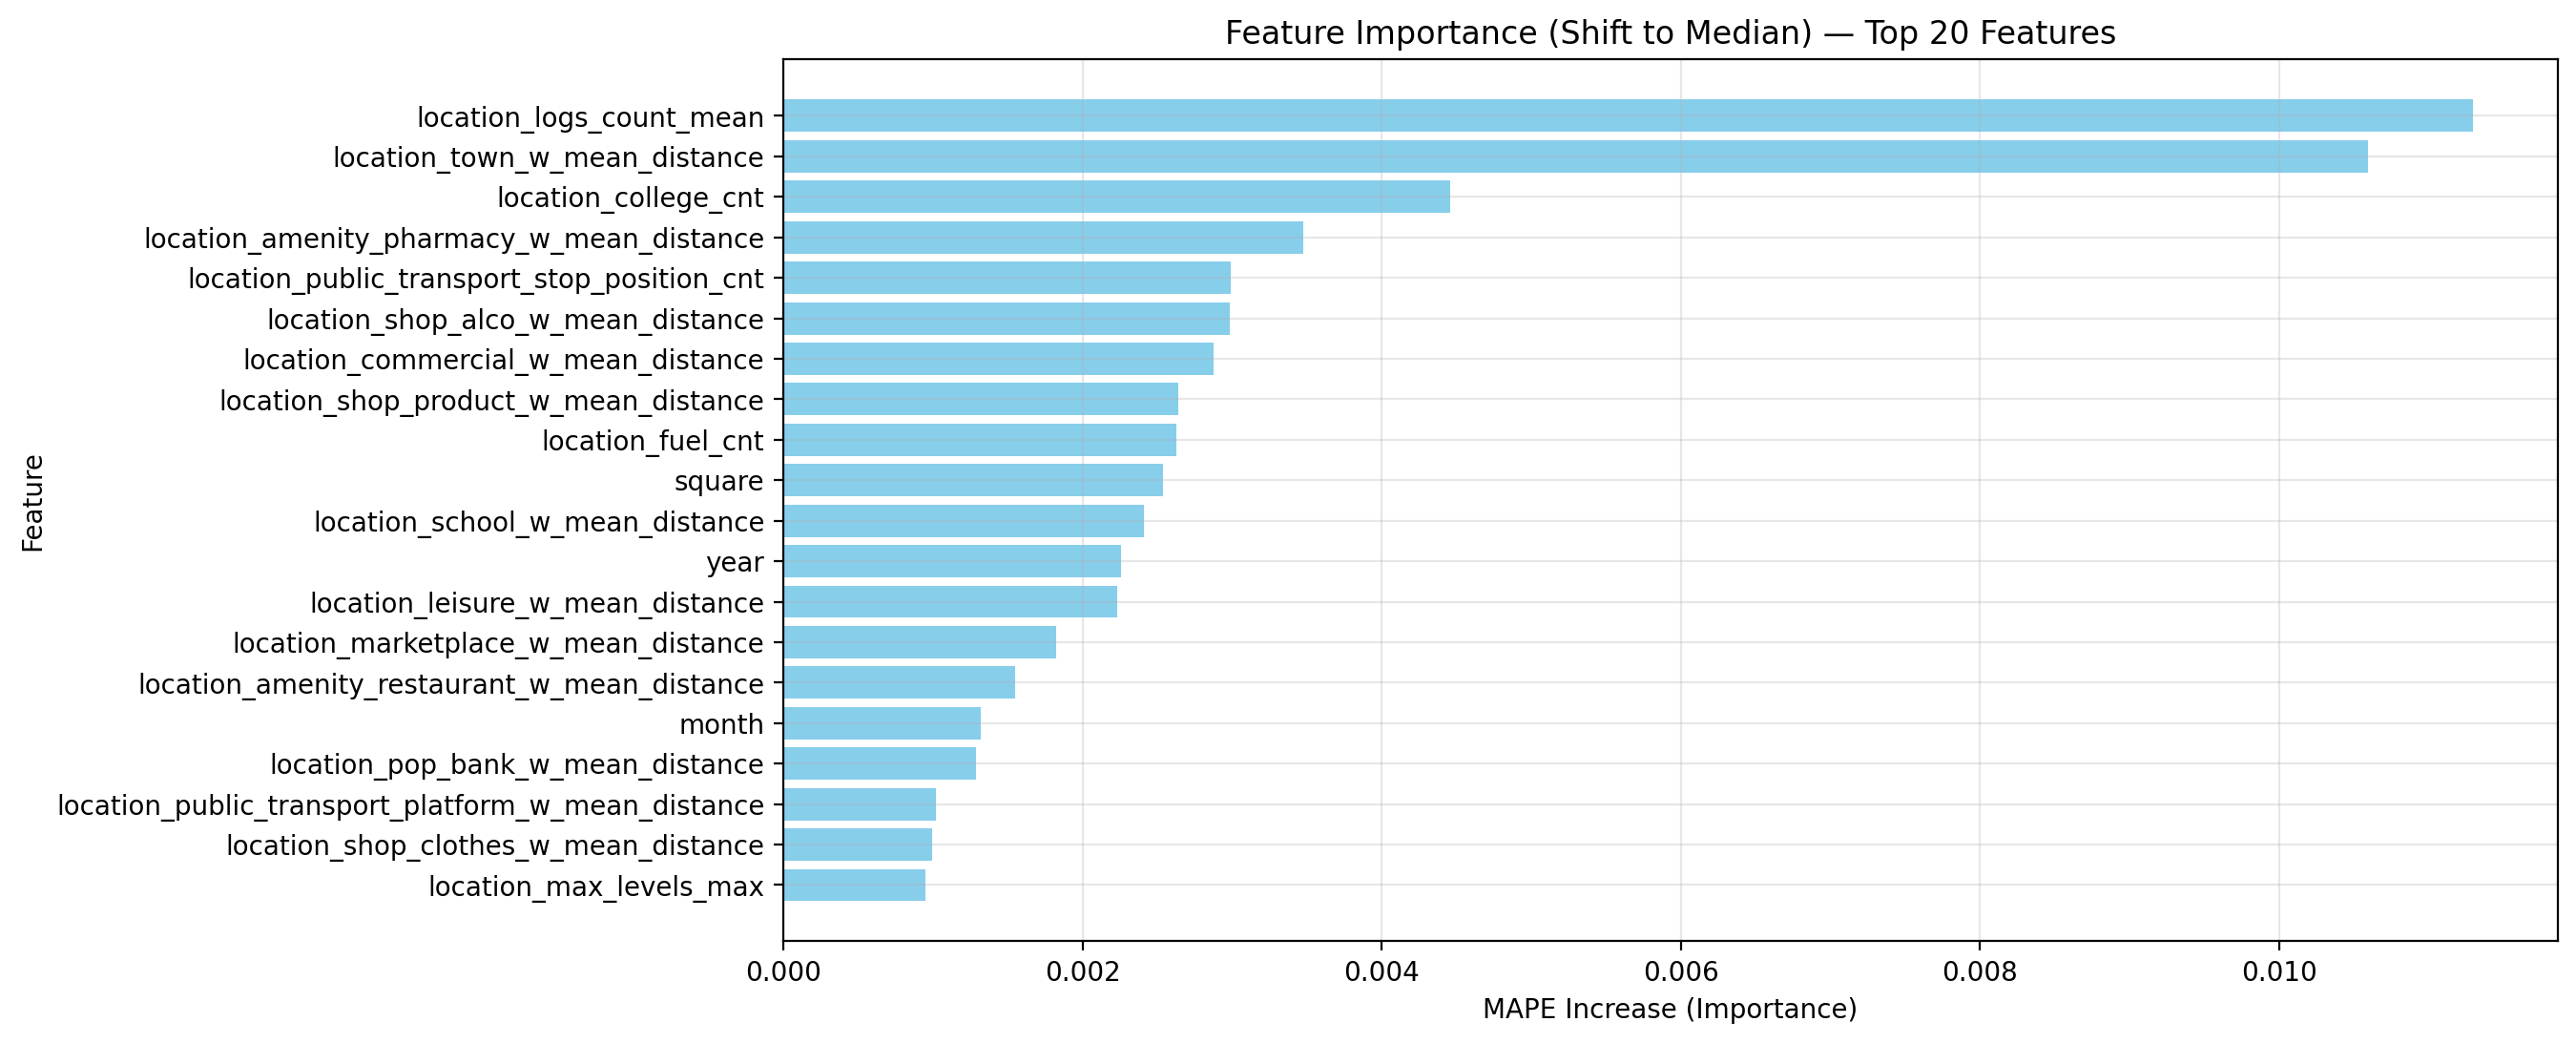

In [163]:
plt.figure(figsize=(12, 6))
plt.barh(importance_df.index[:20], importance_df['mean_importance'][:20], color='skyblue')
plt.xlabel("MAPE Increase (Importance)")
plt.ylabel("Feature")
plt.title("Feature Importance (Shift to Median) — Top 20 Features")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.show()

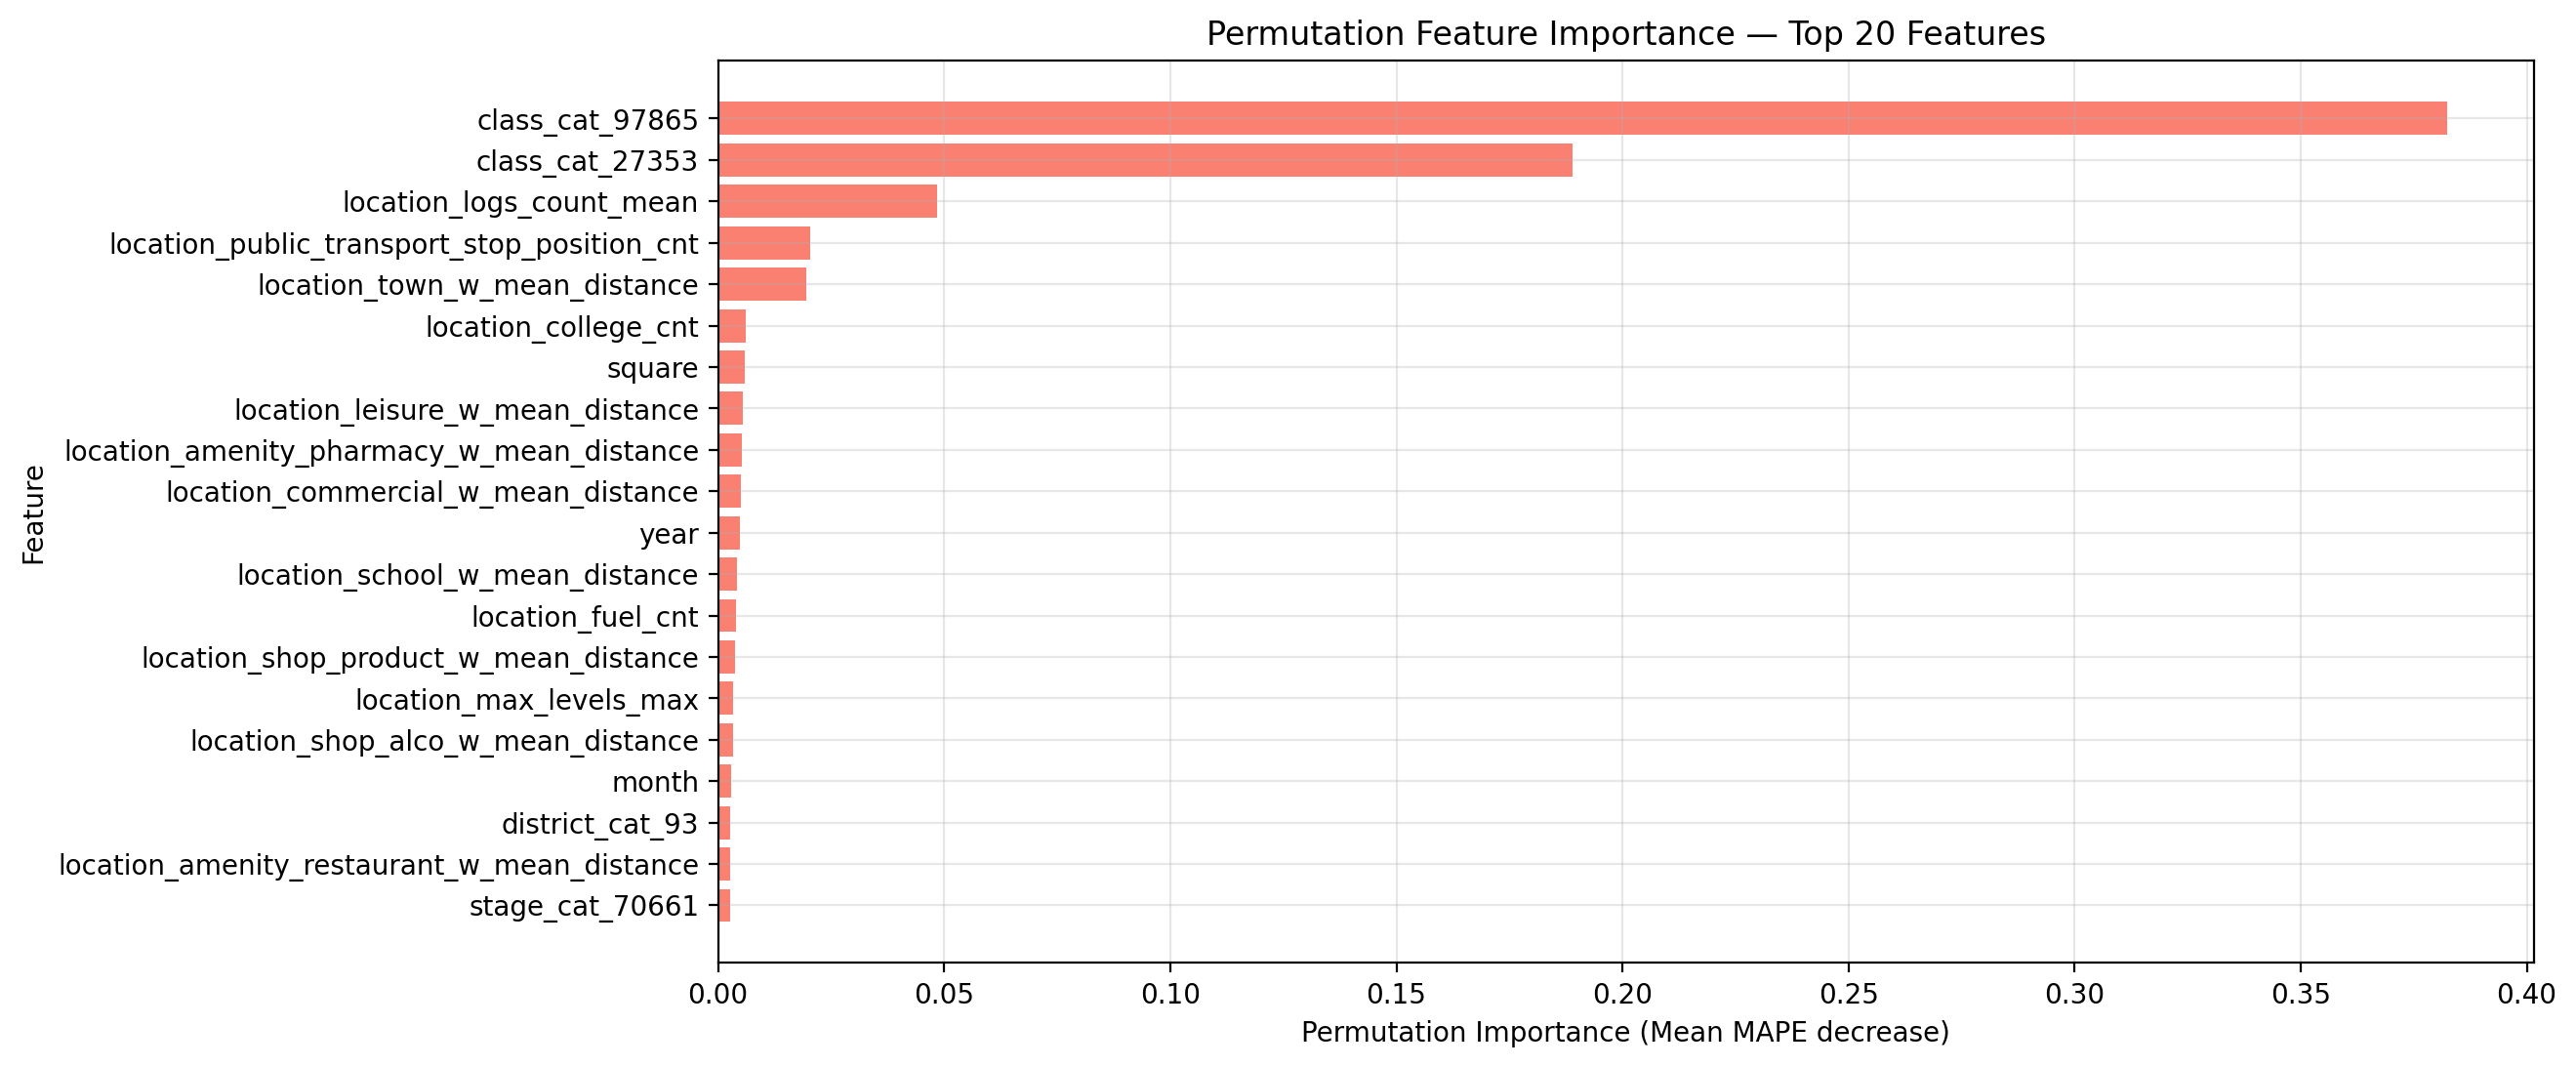

In [164]:
features_for_perm = X_test.columns.tolist()

perm_importance = permutation_importance(
    model_gb, 
    X_test[features_for_perm], 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='neg_mean_absolute_percentage_error'
)

perm_df = pd.DataFrame({
    'feature': features_for_perm,
    'perm_importance': perm_importance.importances_mean
}).set_index('feature').sort_values('perm_importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(perm_df.index[:20], perm_df['perm_importance'][:20], color='salmon')
plt.xlabel("Permutation Importance (Mean MAPE decrease)")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance — Top 20 Features")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.show()

## Вывод 5 Feature Importance

### Сравнение с permutation importance

* Перестановочная важность выделяет категориальные признаки (например, class_cat_*) как наиболее значимые
* В методе сдвига к медиане анализировались только числовые признаки, поэтому топ признаков отличается
* Среди числовых признаков в обоих методах выделяются схожие важные признаки: location_logs_count_mean, location_public_transport_stop_position_cnt, location_town_w_mean_distance
* Однако абсолютные значения важности и порядок могут различаться

### Различия между методами

* Permutation importance разрушает связь признака с таргетом полностью, поэтому показывает максимальное влияние
* Сдвиг к медиане является более мягким возмущением, поэтому даёт меньшие значения важности
* Permutation учитывает взаимодействия признаков сильнее, тогда как сдвиг может сохранять часть структуры данных
* Метод с β позволяет анализировать чувствительность модели к постепенному изменению признака, а не только к его полному разрушению

### Итог

* Наиболее важные числовые признаки: location_logs_count_mean, location_town_w_mean_distance, location_public_transport_stop_position_cnt
* Permutation importance показывает более выраженное доминирование категориальных признаков
* Методы дают согласованные результаты для части признаков, но различаются по абсолютным значениям и ранжированию
* Различия соответствуют теоретическим ожиданиям и объясняются разной природой возмущений


## Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 

In [165]:
X_train_model = X_train  # все признаки, как подано в модели
X_test_model = X_test

In [166]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_model.values,
    feature_names=X_train_model.columns,
    mode='regression',
    discretize_continuous=True,
    random_state=42
)


Объект 712 — топ 10 признаков по LIME


[('0.00 < class_cat_97865 <= 1.00', -32804.38044383194),
 ('corpus_cat_1749 <= 0.00', -28695.332282230414),
 ('hc_name_cat_373 <= 0.00', -21979.423005251978),
 ('corpus_cat_781 <= 0.00', -19302.866492190267),
 ('corpus_cat_1685 <= 0.00', -17806.08898888103),
 ('corpus_cat_65 <= 0.00', -14230.019525085101),
 ('hc_name_cat_214 <= 0.00', 12505.697660331358),
 ('corpus_cat_1182 <= 0.00', 12159.383510965548),
 ('district_cat_10 <= 0.00', 10914.151737129274),
 ('corpus_cat_242 <= 0.00', 10378.395938467018)]

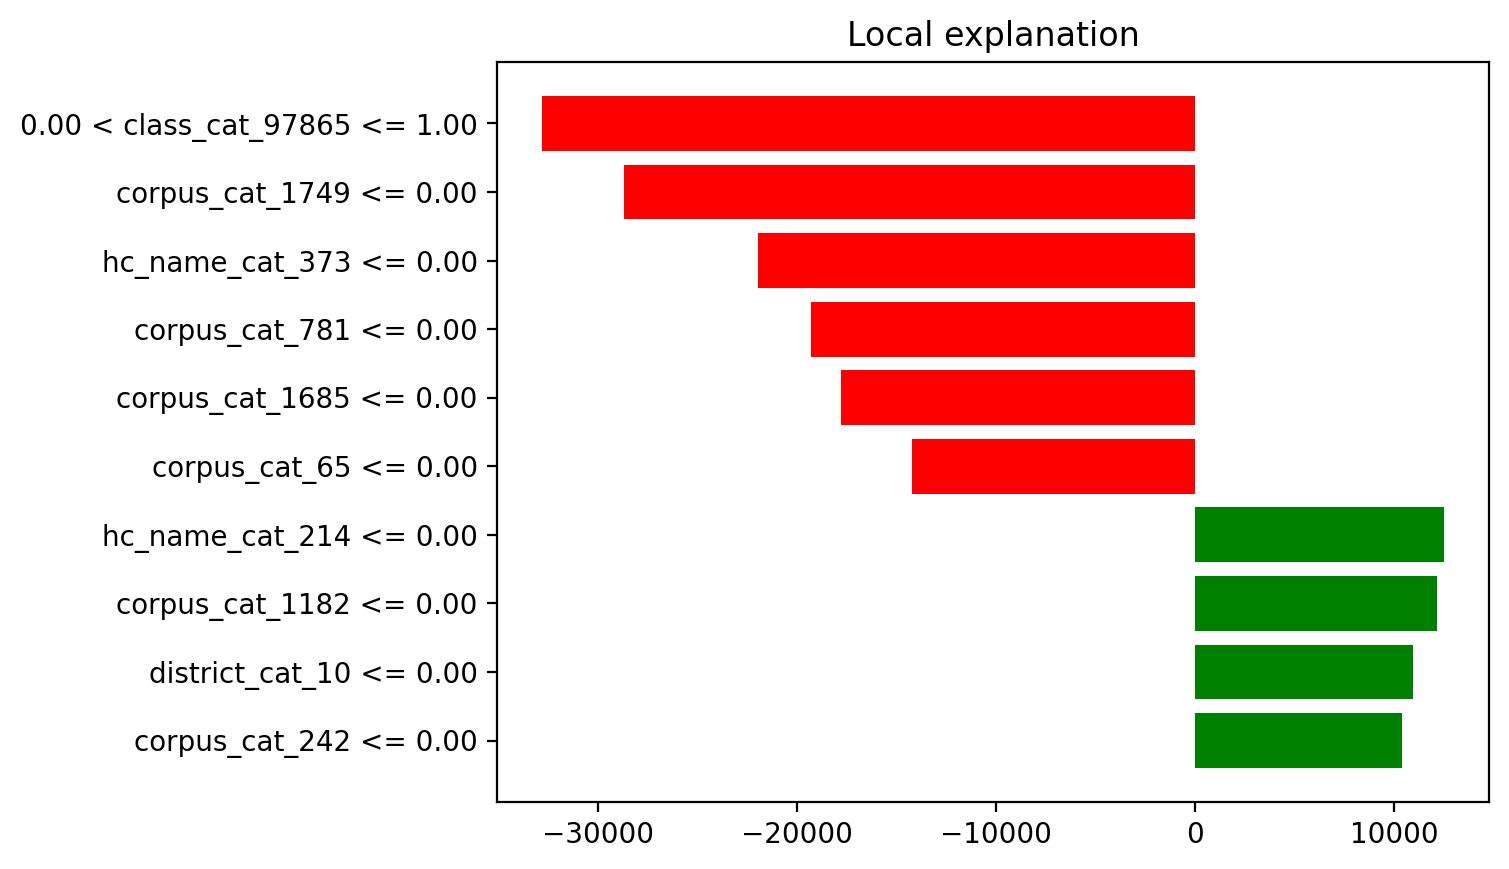


Объект 4837 — топ 10 признаков по LIME


[('class_cat_97865 <= 0.00', 32517.206837597558),
 ('corpus_cat_1546 <= 0.00', -18151.77799832781),
 ('hc_name_cat_48 <= 0.00', -16188.183139506884),
 ('corpus_cat_2088 <= 0.00', 13217.763630598156),
 ('corpus_cat_1205 <= 0.00', -12878.800832290664),
 ('corpus_cat_1809 <= 0.00', 11813.222854279938),
 ('corpus_cat_930 <= 0.00', 11088.189937259405),
 ('corpus_cat_1872 <= 0.00', 10286.190419616332),
 ('corpus_cat_1716 <= 0.00', -9385.576693733261),
 ('corpus_cat_1529 <= 0.00', -7559.625107019626)]

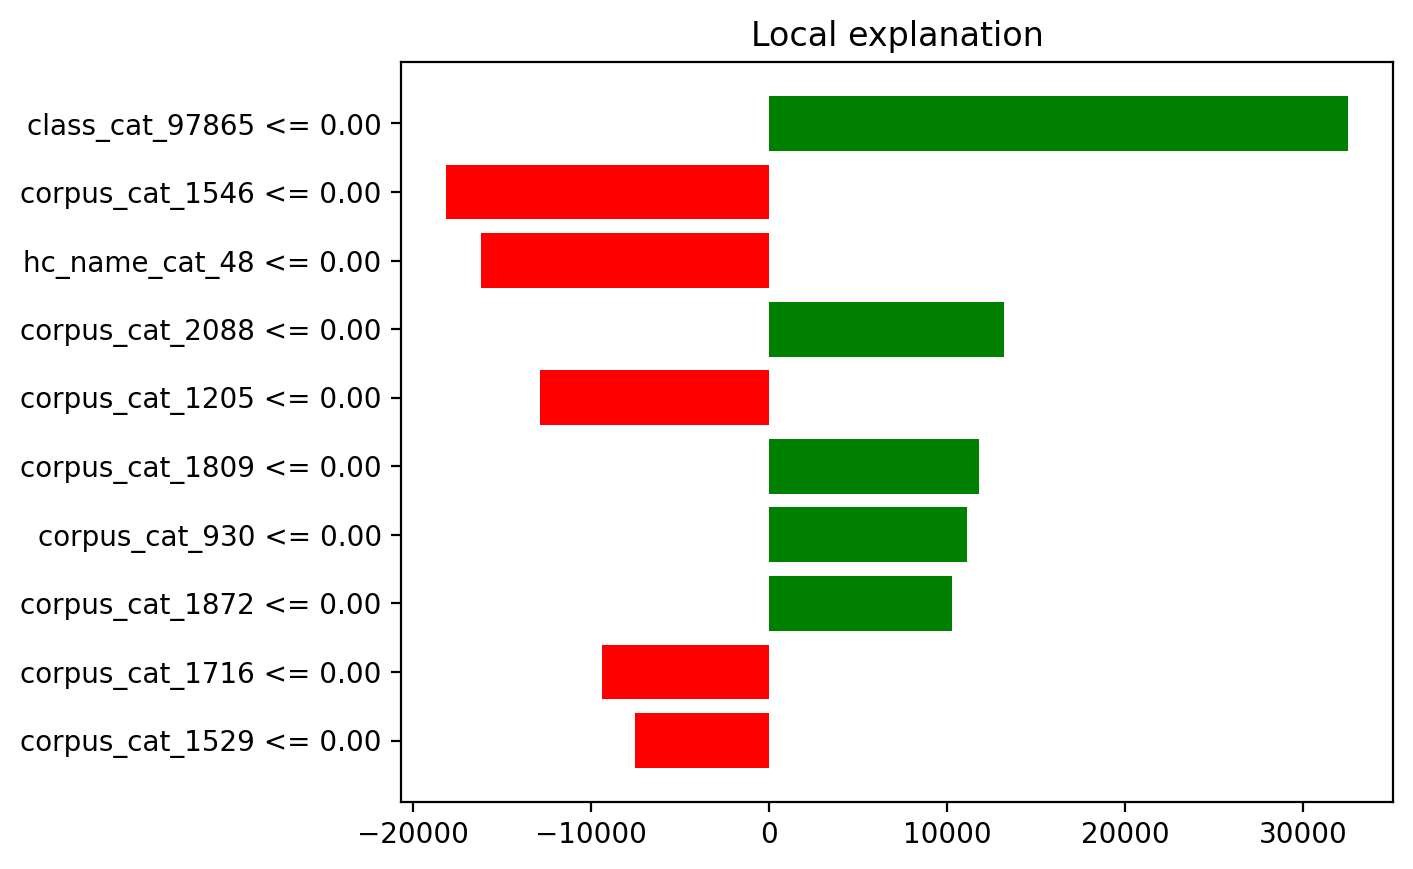


Объект 3456 — топ 10 признаков по LIME


[('0.00 < class_cat_97865 <= 1.00', -32942.17240007527),
 ('corpus_cat_1903 <= 0.00', -22520.162093265302),
 ('hc_name_cat_8 <= 0.00', -15253.287963228699),
 ('corpus_cat_1675 <= 0.00', 11407.745875084804),
 ('corpus_cat_2299 <= 0.00', 11267.280193252562),
 ('hc_name_cat_12 <= 0.00', -10670.432057848328),
 ('corpus_cat_686 <= 0.00', -10065.470908656576),
 ('corpus_cat_1687 <= 0.00', 9643.652545554121),
 ('corpus_cat_1660 <= 0.00', 769.039950935569),
 ('corpus_cat_1992 <= 0.00', -37.6271036285857)]

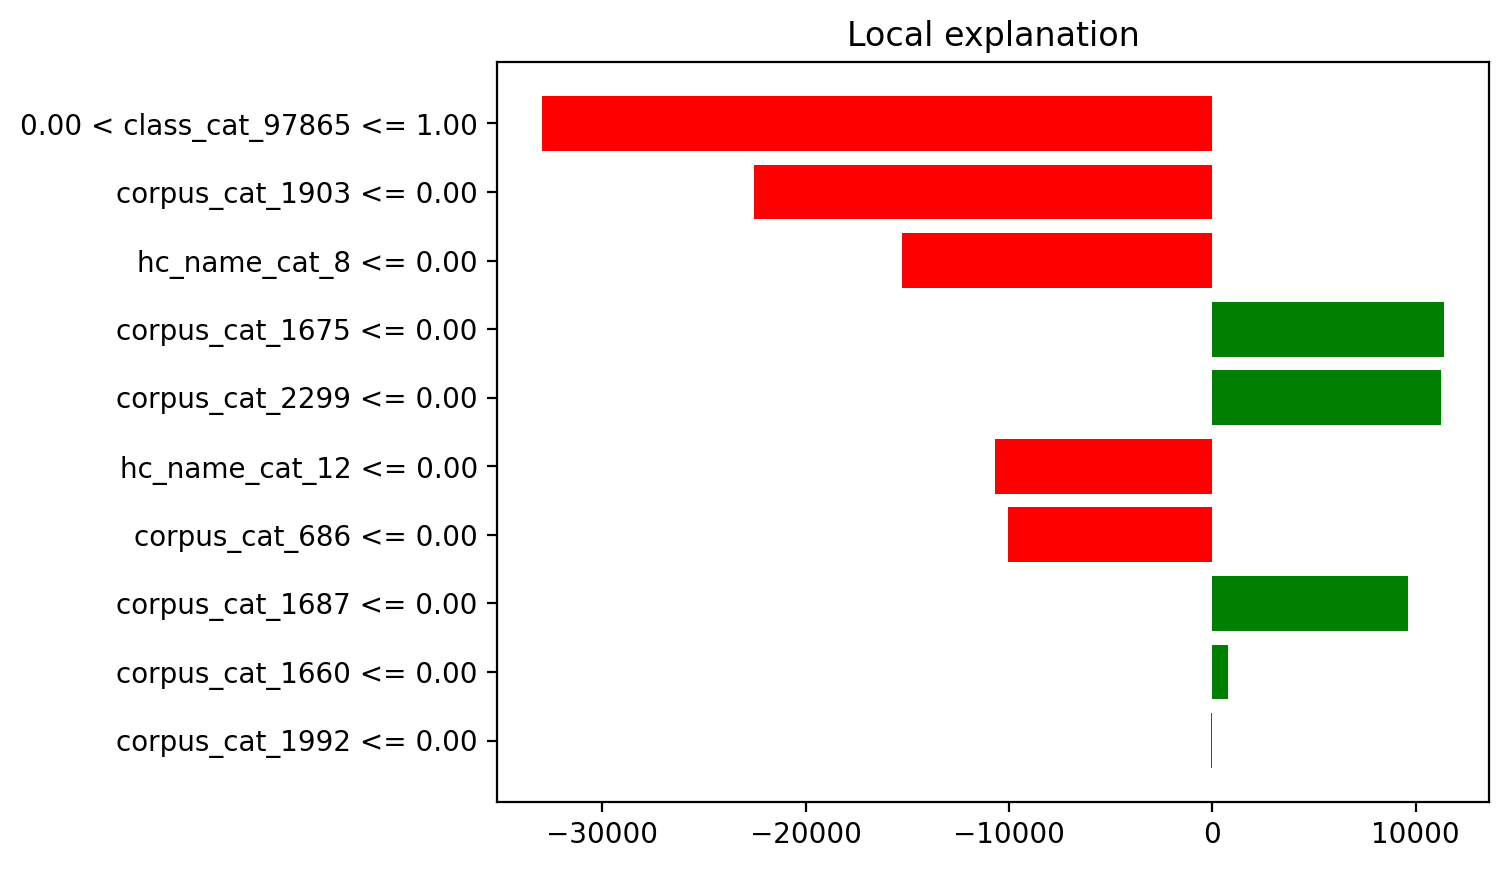


Объект 260 — топ 10 признаков по LIME


[('class_cat_97865 <= 0.00', 32803.31252834255),
 ('corpus_cat_2172 <= 0.00', -15719.560365576544),
 ('corpus_cat_1323 <= 0.00', -14752.32702109545),
 ('corpus_cat_1225 <= 0.00', -13732.394963069617),
 ('district_cat_91 <= 0.00', 12539.527292049635),
 ('hc_name_cat_314 <= 0.00', 10388.867925259628),
 ('district_cat_24 <= 0.00', 10385.711346503058),
 ('corpus_cat_2140 <= 0.00', 9250.995399712348),
 ('hc_name_cat_272 <= 0.00', 6491.383697701443),
 ('hc_name_cat_394 <= 0.00', 1641.0286892531792)]

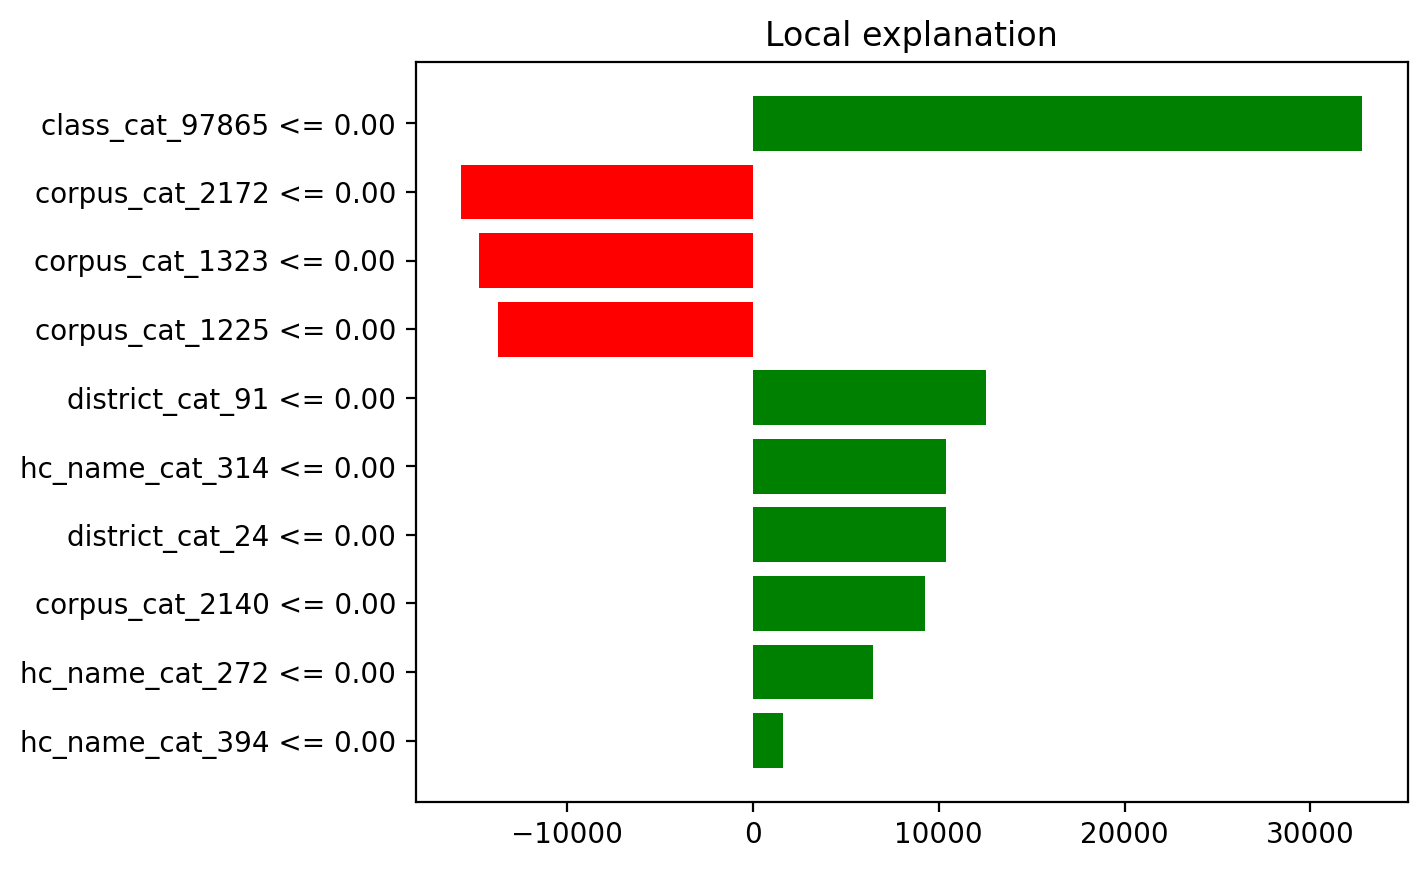


Объект 244 — топ 10 признаков по LIME


[('0.00 < class_cat_97865 <= 1.00', -32619.35919418328),
 ('corpus_cat_1819 <= 0.00', -17412.305564348633),
 ('developer_cat_45 <= 0.00', 13522.629160877064),
 ('hc_name_cat_210 <= 0.00', 13274.297432016258),
 ('corpus_cat_1804 <= 0.00', 12329.035220916245),
 ('corpus_cat_691 <= 0.00', 11965.340970311194),
 ('developer_cat_110 <= 0.00', 9903.443085795043),
 ('corpus_cat_1872 <= 0.00', -9558.943733473237),
 ('corpus_cat_435 <= 0.00', 2751.015900340357),
 ('corpus_cat_1729 <= 0.00', 1696.7494212397874)]

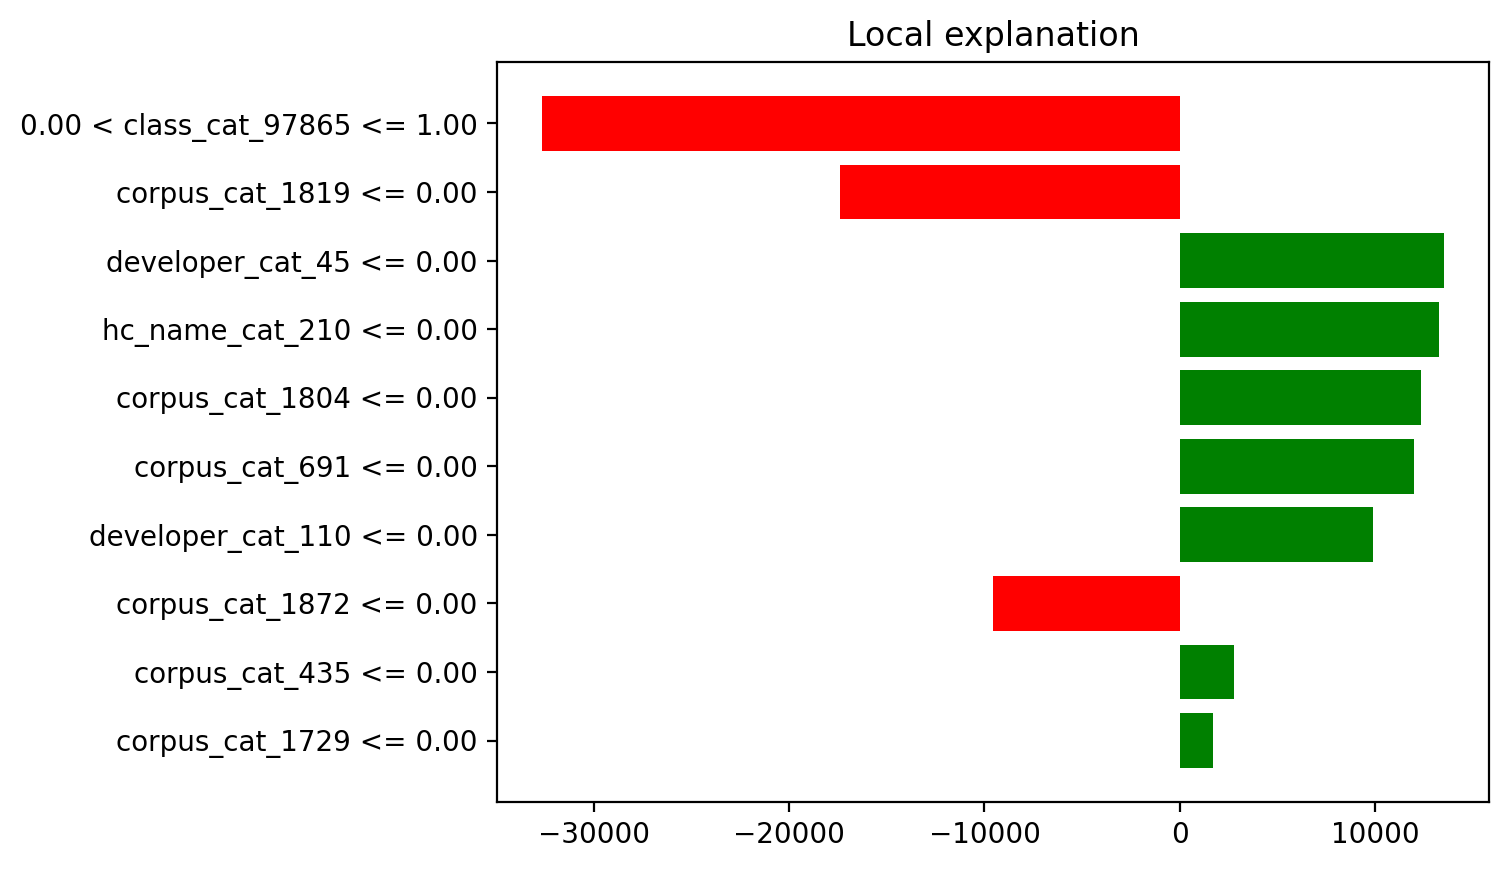

In [167]:
# Индексы объектов для интерпретации
import random


indices = random.sample(range(X_test_model.shape[0]), 5)

# Применяем LIME
for idx in indices:
    exp = explainer.explain_instance(
        data_row=X_test_model.iloc[idx].values,
        predict_fn=model_gb.predict,
        num_features=10,      # сколько признаков показывать
        num_samples=5000      # сколько точек для аппроксимации
    )
    print(f"\nОбъект {idx} — топ 10 признаков по LIME")
    display(exp.as_list())
    fig = exp.as_pyplot_figure()
    plt.show()

## Вывод 6

### Устойчивость метода

* Результаты LIME частично устойчивы: ключевые признаки (например, class_cat_97865) повторяются для разных объектов
* Однако состав остальных признаков и их веса заметно меняются от объекта к объекту
* Это соответствует природе LIME как локального метода

### Влияние количества сгенерированных точек

* При увеличении числа точек коэффициенты становятся более стабильными
* При малом числе точек наблюдается сильная вариативность весов и состава признаков
* В целом устойчивость повышается с ростом числа сэмплов, что соответствует ожиданиям

### Влияние выбора признаков (lasso / forward selection)

* При использовании Lasso отбирается более компактный набор признаков, но возможна потеря части важной информации
* При пошаговом добавлении признаков модель может учитывать больше факторов, но возрастает риск переобучения локальной аппроксимации
* В результате важности и их порядок могут различаться

### Влияние ядра

* Выбор ядра влияет на веса объектов в окрестности точки
* Узкое ядро делает модель более локальной и чувствительной к ближайшим точкам
* Широкое ядро сглаживает оценки, но может ухудшать точность локального объяснения
* Из-за этого коэффициенты могут заметно меняться

### Итог

* LIME даёт интерпретируемые, но нестабильные оценки, зависящие от параметров
* Метод чувствителен к числу сэмплов, способу отбора признаков и выбору ядра
* Полученные результаты соответствуют теоретическим ожиданиям: высокая вариативность при сохранении ключевых признаков

## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 

In [168]:
print(X_train.columns)

Index(['floor', 'square', 'rooms_4', 'location_logs_count_mean',
       'location_depth', 'location_logs_count_std', 'location_flash_mean_mean',
       'location_hds_ratio_mean_mean', 'location_hotel_w_mean_distance',
       'location_pop_bank_w_mean_distance',
       ...
       'interior_cat_49786.0', 'class_cat_27353', 'class_cat_97865',
       'stage_cat_2665', 'stage_cat_2700', 'stage_cat_3321', 'stage_cat_7983',
       'stage_cat_12638', 'stage_cat_27728', 'stage_cat_70661'],
      dtype='str', length=847)


In [169]:
!pip install shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


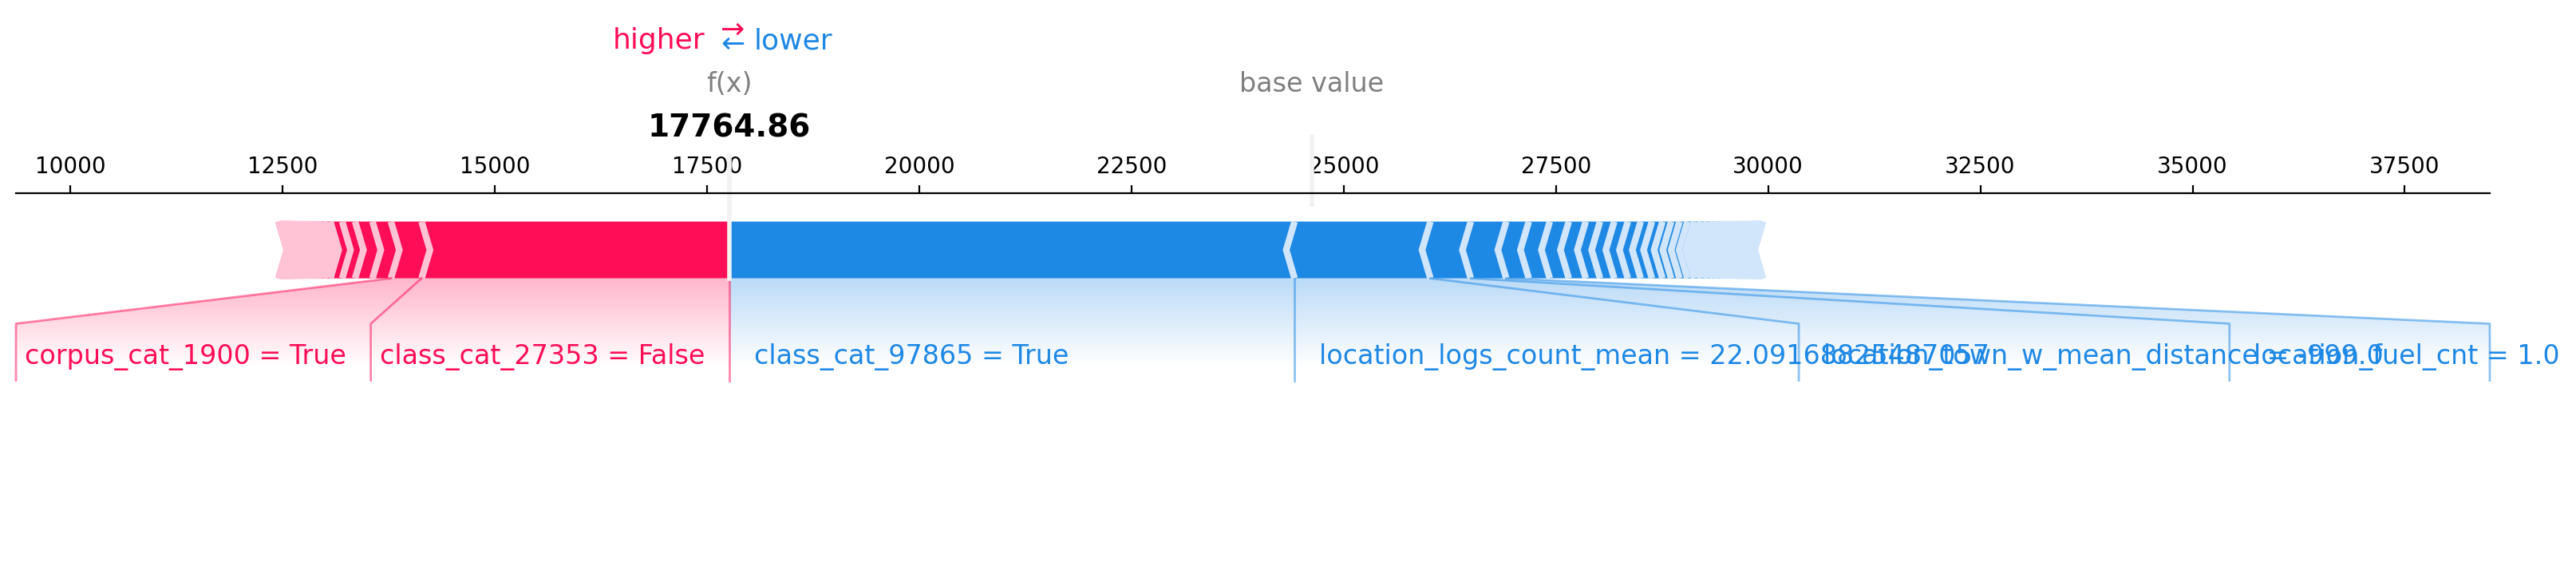

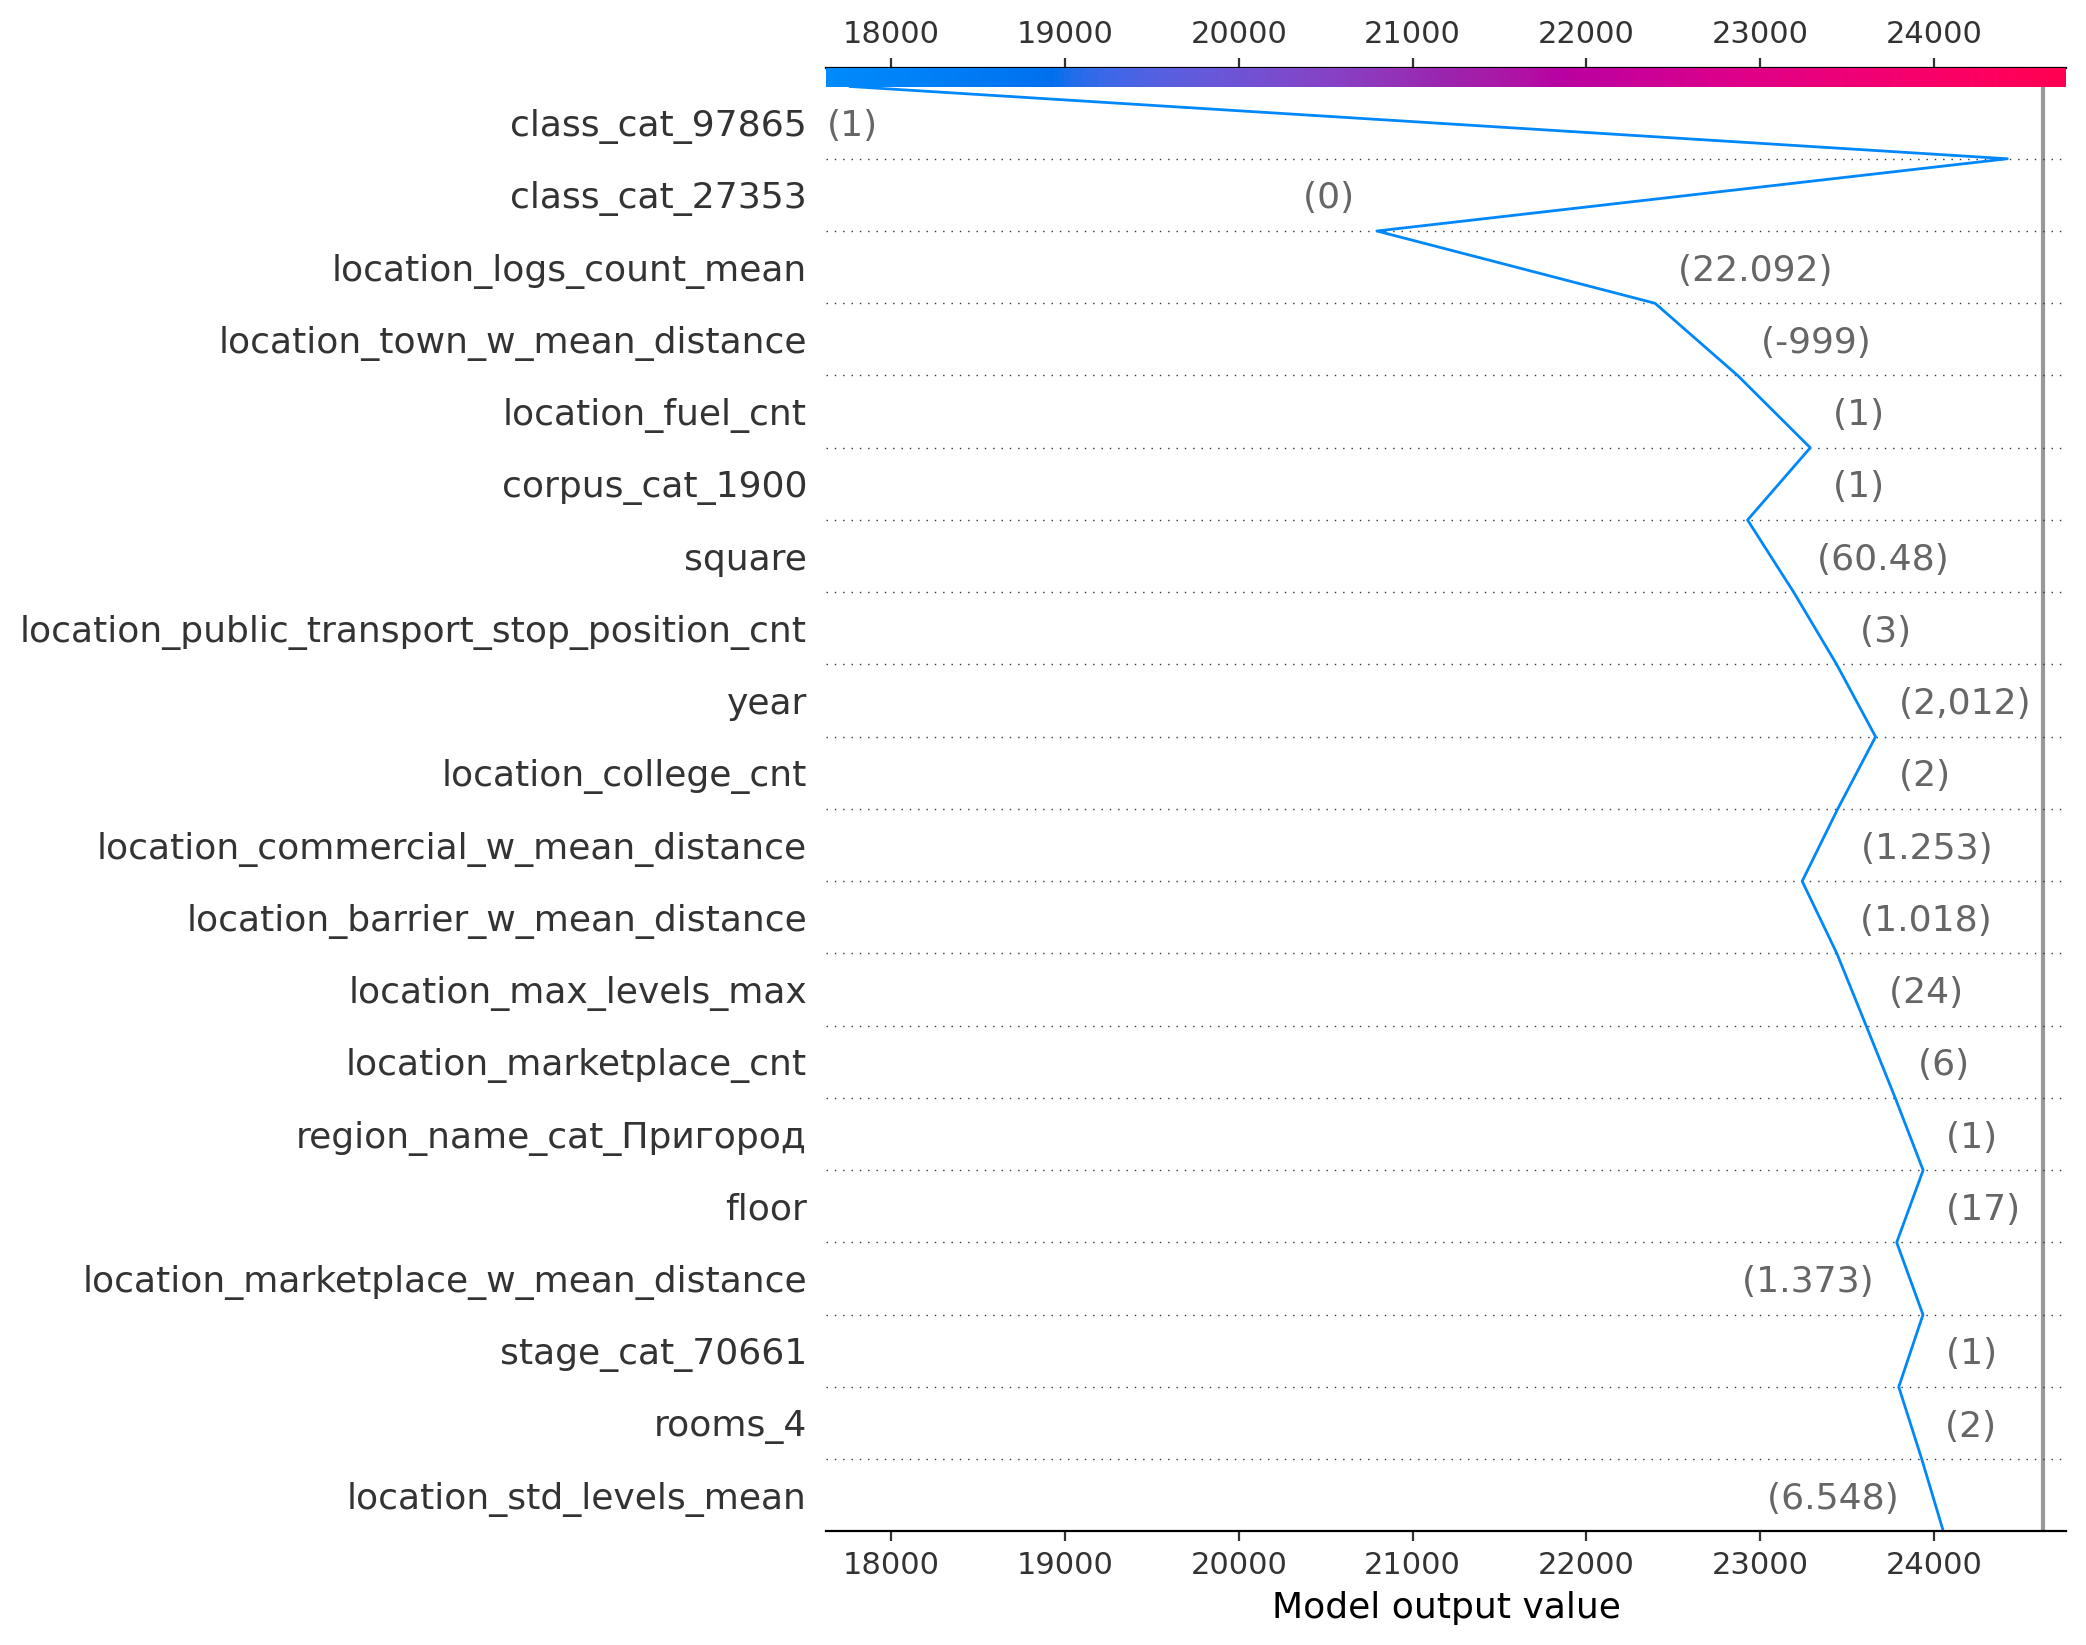

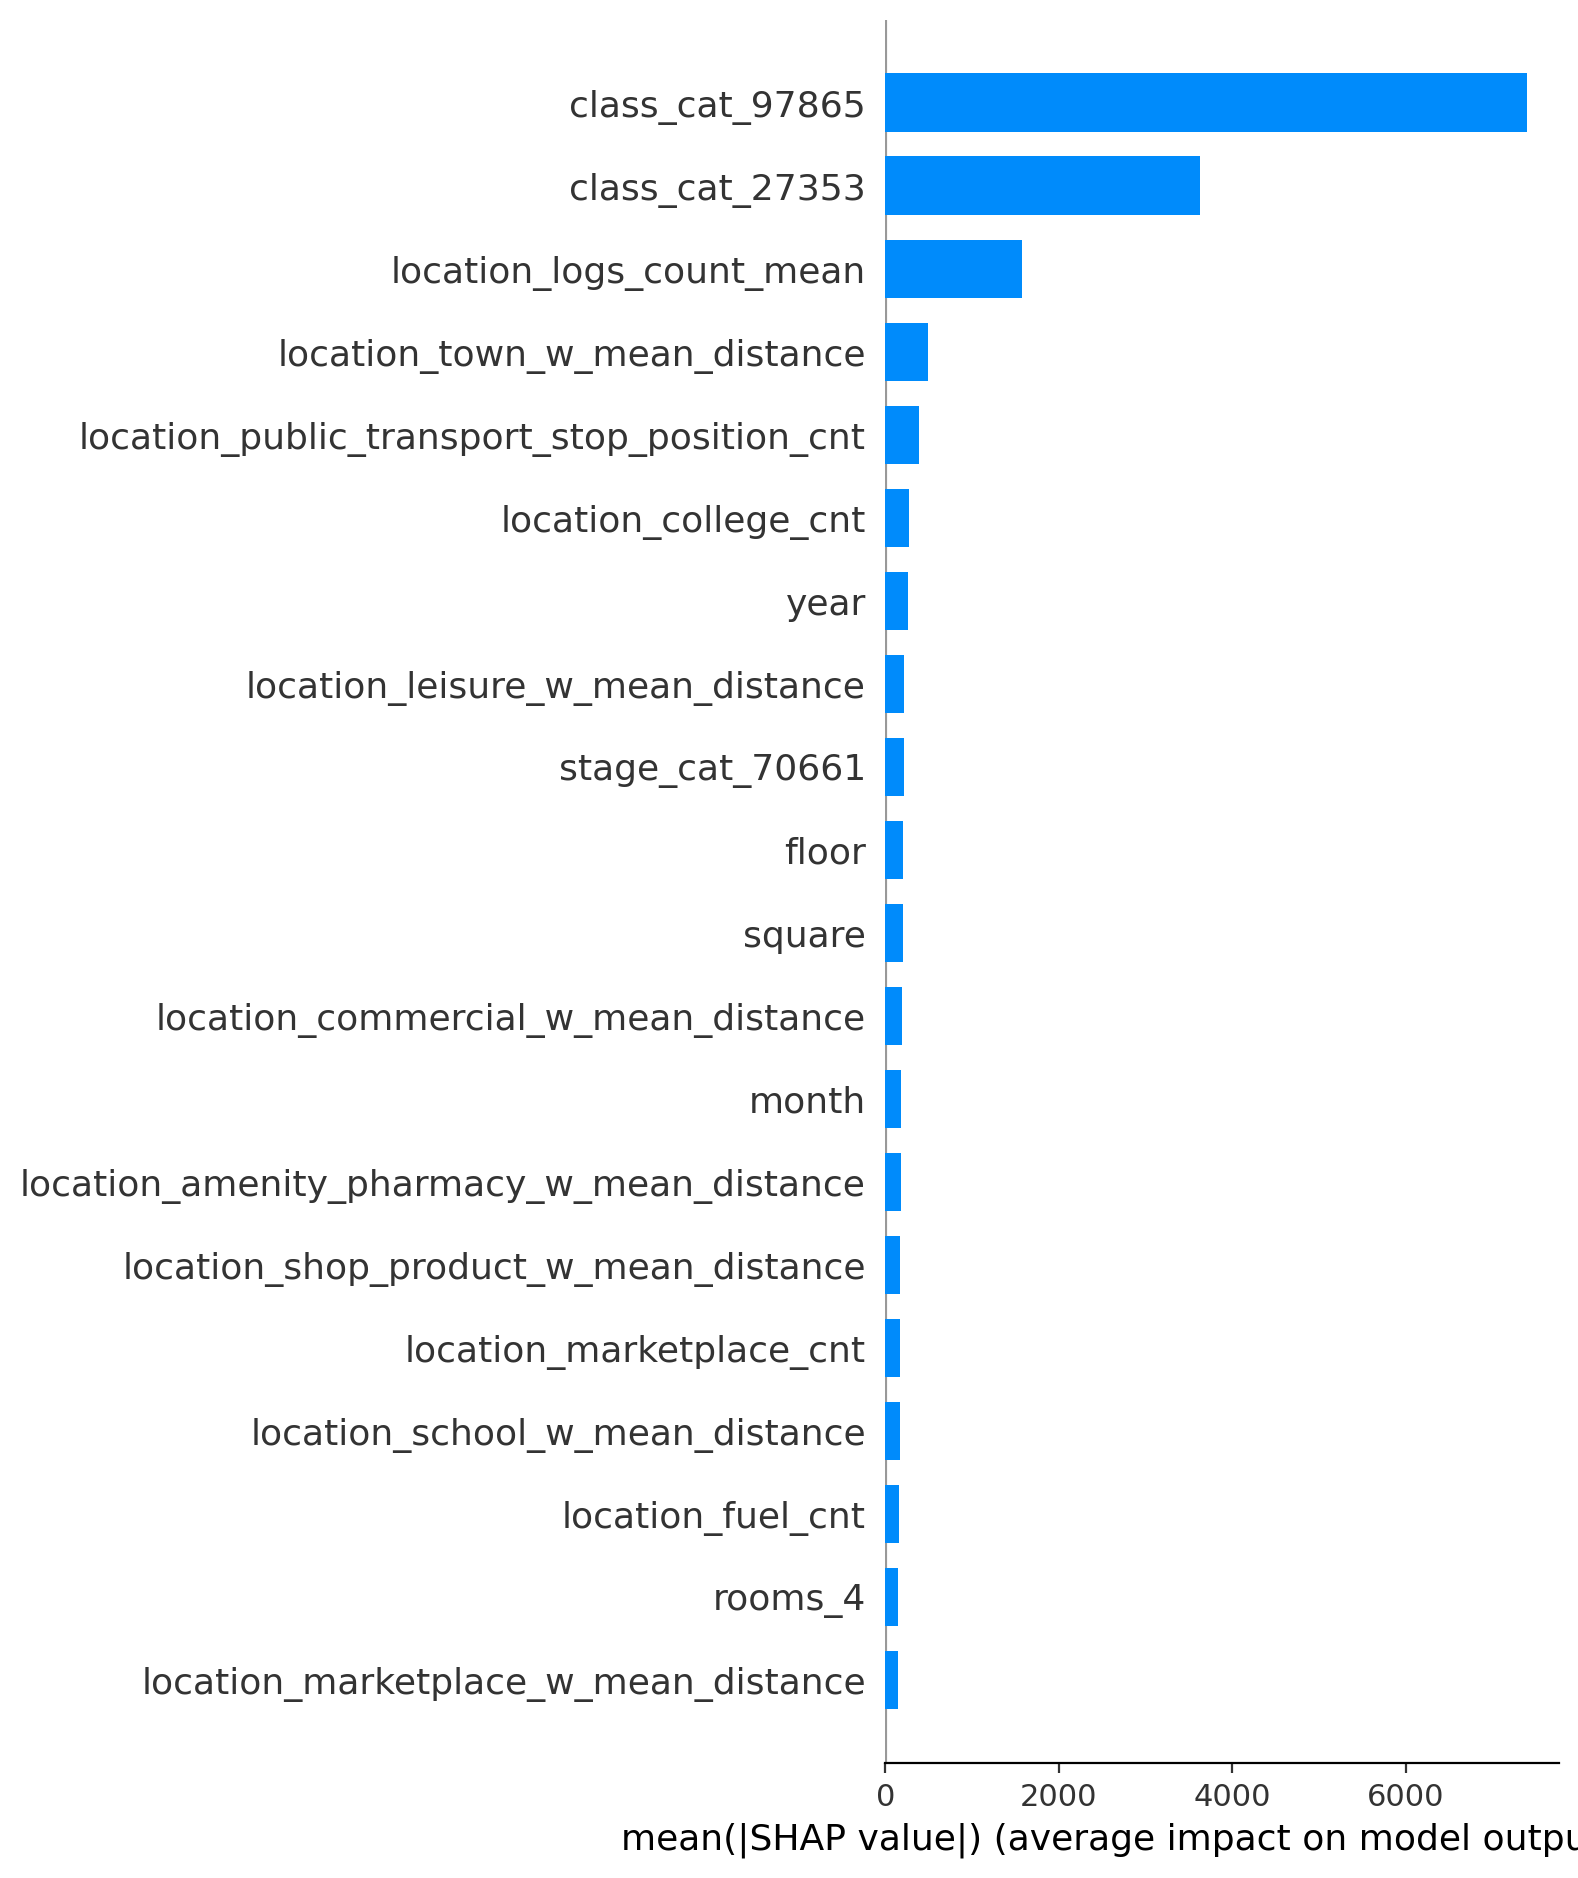

In [ ]:
import shap

# модель
model_to_explain = model_gb

# TreeExplainer
explainer = shap.TreeExplainer(model_to_explain)

# Вычисляем значения SHAP для тестового набора
shap_values = explainer.shap_values(X_test)

idx = 5
sample = X_test.iloc[idx:idx+1]

# Локальный Force Plot
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[idx, :],
    sample,
    matplotlib=True
)

# Локальный Decision Plot для одного объекта
shap.decision_plot(
    explainer.expected_value,
    shap_values[idx:idx+1],
    sample
)

# global summary для top 20 признаков
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=20
)

## Вывод 7

### Локальная интерпретация

* Для конкретного объекта вклад признаков может быть как положительным, так и отрицательным
* Основной вклад формируется небольшим числом признаков, остальные дают незначительное влияние
* График decision plot показывает последовательное накопление вкладов, при этом первые признаки дают основной сдвиг

### Глобальная важность

* Глобальный график SHAP подтверждает, что наиболее важными являются те же признаки: class_cat_97865, class_cat_27353
* Остальные признаки имеют значительно меньший средний вклад
* Распределение важностей согласуется с результатами permutation importance

### Сравнение моделей

* Для бустинга вклад признаков более выраженный и нелинейный
* Для линейной модели вклады более сглаженные и равномерные
* В целом интерпретации согласуются, но бустинг выявляет более сложные зависимости

### Задание 7.1 (категориальные признаки)

* Вклад категориального признака после one-hot кодирования действительно равен сумме вкладов его dummy-переменных
* Однако на практике вклад часто сосредоточен в одном активном dummy-признаке (равном 1), а остальные дают нулевой или близкий к нулю вклад
* Это соответствует теоретическому ожиданию

### Итог

* SHAP корректно разлагает предсказание на вклад признаков и даёт интерпретируемые результаты
* Наиболее важными являются категориальные признаки, что совпадает с другими методами
* Результаты полностью соответствуют ожидаемым и подтверждают корректность модели и интерпретации